# 📊 Análisis de Estadísticas de Empleo — ENAHO Capítulo 500
## Periodo: 2015 – 2025

Este notebook replica y amplía el script Stata `script.do` del MTPE/INEI sobre el módulo 500 (Empleo e Ingresos) de la ENAHO.  
Incluye:
- Carga y limpieza de datos por año
- Indicadores clave: PEA, Tasa de Actividad, Desempleo, Informalidad, Inactividad
- Análisis por área de residencia, región natural y departamento
- **Series temporales** 2015‑2025
- Estadísticas comparativas inter‑anuales
- Exportación del CSV final para predicción

---

## 0. Configuración e Importaciones

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import torch

# ── GPU setup ─────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    gpu_name  = torch.cuda.get_device_name(0)
    gpu_mem   = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'🚀 GPU activa: {gpu_name}  ({gpu_mem:.1f} GB VRAM)')
    print(f'   CUDA {torch.version.cuda} | PyTorch {torch.__version__}')
    torch.cuda.empty_cache()
else:
    print('⚠️  Sin GPU — usando CPU')
    
# ── Estilo visual ──────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': '#FFFFFF',
    'axes.facecolor': '#FFFFFF',
    'axes.grid': True,
    'grid.color': '#ECECEC',
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.spines.bottom': True,
    'axes.edgecolor': '#CCCCCC',
    'font.family': 'sans-serif',
    'text.color': '#2D3748',
    'axes.labelcolor': '#2D3748',
    'xtick.color': '#4A5568',
    'ytick.color': '#4A5568',
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'legend.frameon': True,
    'legend.facecolor': '#FFFFFF',
    'legend.edgecolor': '#E2E8F0',
    'legend.fontsize': 9,
})
PALETTE = sns.color_palette('tab10')

# ── Rutas ──────────────────────────────────────────────────────────────────
DATA_DIR   = '../data/raw/enaho01a-500'
OUTPUT_DIR = '../data/interim'
YEARS      = list(range(2015, 2026))

print('✅ Librerías cargadas correctamente')
print(f'   Años a procesar: {YEARS}')

os.makedirs('imagenes', exist_ok=True)
print('📁 Carpeta imagenes/ lista')


🚀 GPU activa: NVIDIA GeForce RTX 3080  (10.5 GB VRAM)
   CUDA 11.8 | PyTorch 2.4.1+cu118
✅ Librerías cargadas correctamente
   Años a procesar: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
📁 Carpeta imagenes/ lista


---
## 1. Carga y Preprocesamiento de Datos

In [2]:
# ── Columnas clave según script.do ────────────────────────────────────────
KEY_COLS = [
    'AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR', 'UBIGEO',
    'DOMINIO', 'ESTRATO',
    'P203',    # número de orden del miembro
    'P204',    # residente habitual
    'P205',    # ausente
    'P206',    # visitante
    'P207',    # sexo
    'P208A',   # edad
    'P209',    # nivel educativo
    'P301A',   # nivel de educación alcanzado
    'P500I',   # código informante
    'OCU500',  # condición de ocupación (1=ocupado,2=desoc.abierto,3=desoc.oculto,4=NoPEA)
    'OCUPINF', # informalidad (1=informal,2=formal)
    'FAC500A', # factor de expansión
    'IMPUTADO',
    # ingresos laborales
    'I518', 'I513t', 'I520', 'I530A',
    'I524A1', 'I524B1', 'I524C1', 'I524D1', 'I524E1',
    # horas
    'T546', 'T549',
    # contrato laboral (para informalidad 2024-2025)
    'P511A',
    # formalidad empresa/negocio (para TEI 2024-2025)
    'P510A1', 'P510B',
]

def encode_col(col_name):
    """Normaliza nombre de columna para búsqueda insensible a encoding."""
    return col_name.upper().strip()

def load_year(year):
    """Carga el CSV de un año y retorna un DataFrame limpio."""
    fpath = os.path.join(DATA_DIR, f'Enaho01a-{year}-500.csv')
    # Auto-detectar separador (2025 usa ';', 2015-2024 usan ',')
    with open(fpath, 'r', encoding='latin1', errors='replace') as _f:
        _first = _f.readline()
    _sep = ';' if _first.count(';') > _first.count(',') else ','
    df = pd.read_csv(fpath, encoding='latin1', low_memory=False, sep=_sep, on_bad_lines='skip')
    # Normalizar nombres de columnas
    df.columns = [c.upper().strip() for c in df.columns]
    # Renombrar 'A\xd1O' → 'AÑO' si viene con encoding raro
    rename_map = {c: 'AÑO' for c in df.columns if 'AO' in c and len(c) <= 4}
    df.rename(columns=rename_map, inplace=True)

    # Conservar solo columnas disponibles del listado clave
    available = [c for c in KEY_COLS if c in df.columns]
    df = df[available].copy()

    # Asegurar columna AÑO
    if 'AÑO' not in df.columns:
        df['AÑO'] = year
    else:
        df['AÑO'] = year   # forzar int

    # ── Filtro p500i != '00'  (solo informantes válidos) ──────────────────
    if 'P500I' in df.columns:
        df['P500I'] = df['P500I'].astype(str).str.strip().str.zfill(2)
        df = df[df['P500I'] != '00'].copy()

    # ── Variable RESIDENTE  (p204==1 & p205==2) | (p204==2 & p206==1) ───
    p204 = pd.to_numeric(df.get('P204', pd.Series(np.nan, index=df.index)), errors='coerce')
    p205 = pd.to_numeric(df.get('P205', pd.Series(np.nan, index=df.index)), errors='coerce')
    p206 = pd.to_numeric(df.get('P206', pd.Series(np.nan, index=df.index)), errors='coerce')
    df['RESIDENTE'] = (((p204 == 1) & (p205 == 2)) | ((p204 == 2) & (p206 == 1))).astype(int)

    # ── ÁREA (recode estrato 1/5→1, 6/8→2) ───────────────────────────────
    estrato = pd.to_numeric(df['ESTRATO'], errors='coerce')
    df['AREA'] = np.where(estrato.between(1,5), 1,
                 np.where(estrato.between(6,8), 2, np.nan))
    df['AREA_LABEL'] = df['AREA'].map({1:'Urbano', 2:'Rural'})

    # ── REGIÓN NATURAL (recode dominio) ───────────────────────────────────
    dominio = pd.to_numeric(df['DOMINIO'], errors='coerce')
    df['REGION'] = np.where(dominio.isin([1,2,3,8]), 1,
                   np.where(dominio.between(4,6), 2,
                   np.where(dominio == 7, 3, np.nan)))
    df['REGION_LABEL'] = df['REGION'].map({1:'Costa', 2:'Sierra', 3:'Selva'})

    # ── DEPARTAMENTO (basado en ubigeo) ───────────────────────────────────
    ubigeo = df['UBIGEO'].astype(str).str.strip()
    # Normalizar a 6 dígitos (algunos ubigeos vienen sin el cero inicial, ej: '30101' → '030101')
    ubigeo_6 = ubigeo.str.zfill(6)
    dep_code = pd.to_numeric(ubigeo_6.str[:2], errors='coerce').astype('Int64')
    df['DEP'] = dep_code
    # Códigos INEI: 01-25 (15=Lima completo, 16=Loreto, ..., 25=Ucayali)
    DEP_LABEL_MAP = {
        1:'Amazonas', 2:'Ancash', 3:'Apurímac', 4:'Arequipa',
        5:'Ayacucho', 6:'Cajamarca', 7:'Callao', 8:'Cusco',
        9:'Huancavelica', 10:'Huánuco', 11:'Ica', 12:'Junín',
        13:'La Libertad', 14:'Lambayeque', 15:'Lima Metropolitana',
        16:'Loreto', 17:'Madre de Dios', 18:'Moquegua',
        19:'Pasco', 20:'Piura', 21:'Puno', 22:'San Martín',
        23:'Tacna', 24:'Tumbes', 25:'Ucayali'
    }
    # Separar Lima Metropolitana (ubigeo[:4]=='1501') de Lima Provincias (resto)
    is_lima = dep_code == 15
    df['DEP_LABEL'] = dep_code.map(DEP_LABEL_MAP)
    df.loc[is_lima & (ubigeo_6.str[:4] != '1501'), 'DEP_LABEL'] = 'Lima'
    df.loc[is_lima & (ubigeo_6.str[:4] == '1501'), 'DEP_LABEL'] = 'Lima Metropolitana'

    # ── GRUPO DE EDAD ─────────────────────────────────────────────────────
    edad = pd.to_numeric(df.get('P208A', pd.Series(np.nan, index=df.index)), errors='coerce')
    df['GEDAD'] = np.where(edad.between(14,24), 1,
                  np.where(edad.between(25,44), 2,
                  np.where(edad >= 45, 3, np.nan)))
    df['GEDAD_LABEL'] = df['GEDAD'].map({1:'14-24', 2:'25-44', 3:'45+'})

    df['OGEDAD'] = np.where(edad.between(14,24), 1,
                   np.where(edad.between(25,44), 2,
                   np.where(edad.between(45,64), 3,
                   np.where(edad >= 65, 4, np.nan))))
    df['OGEDAD_LABEL'] = df['OGEDAD'].map({1:'14-24', 2:'25-44', 3:'45-64', 4:'65+'})

    # ── INDICADORES ───────────────────────────────────────────────────────
    ocu = pd.to_numeric(df.get('OCU500', pd.Series(np.nan, index=df.index)), errors='coerce')
    df['OCU500_N'] = ocu

    df['PEA']             = (ocu < 3).astype(float)
    df['OCUPADO']         = (ocu == 1).astype(float)
    df['DESOC_ABIERTO']   = (ocu == 2).astype(float)
    df['DESOC_OCULTO']    = (ocu == 3).astype(float)
    df['TASA_ACTIVIDAD']  = (ocu < 3).astype(float)
    df['TASA_INACTIVIDAD']= ((ocu == 3) | (ocu == 4)).astype(float)

    # TEI: informalidad — OCUPINF para 2015-2023, P511A para 2024-2025
    # ── TEI: Tasa de Empleo Informal ──────────────────────────────────────
    # 2015-2023: OCUPINF (1=informal, 2=formal) — metodología original INEI
    # 2024-2025: índice compuesto (OCUPINF no existe):
    #   Informal si CUALQUIERA de los indicadores aplica como informal:
    #     · P510A1 == '3'  → empresa sin RUC / SUNAT (informal)
    #     · P510B  == '2'  → empresa sin libros de contabilidad (informal)
    #     · P511A  == '7'  → trabajador sin contrato (informal)
    #   Formal si todos los indicadores disponibles muestran formalidad.
    #   NaN si ningún indicador aplica al trabajador.
    ocupinf = pd.to_numeric(df.get('OCUPINF', pd.Series(np.nan, index=df.index)), errors='coerce')
    if ocupinf.notna().any():
        # OCUPINF disponible (2015-2023)
        df['TEI'] = np.where(ocupinf.notna(), (ocupinf == 1).astype(float), np.nan)
    else:
        # Índice compuesto para 2024-2025
        # P510A1: registro SUNAT del negocio (1,2=formal | 3=informal)
        _p510a1     = df.get('P510A1', pd.Series('', index=df.index)).astype(str).str.strip()
        _p510a1_inf = (_p510a1 == '3')
        _p510a1_ok  = _p510a1.isin(['1', '2', '3'])

        # P510B: contabilidad del negocio (1=formal | 2=informal)
        _p510b     = df.get('P510B', pd.Series('', index=df.index)).astype(str).str.strip()
        _p510b_inf = (_p510b == '2')
        _p510b_ok  = _p510b.isin(['1', '2'])

        # P511A: tipo de contrato laboral (1-6=formal | 7=informal)
        _p511     = df.get('P511A', pd.Series('', index=df.index)).astype(str).str.strip()
        _p511_inf = (_p511 == '7')
        _p511_ok  = _p511.isin(['1', '2', '3', '4', '5', '6', '7'])

        # Informal si AL MENOS UN indicador es informal (OR inclusivo)
        # Solo asignar TEI si al menos un indicador aplica
        _any_ok  = _p510a1_ok | _p510b_ok | _p511_ok
        _any_inf = _p510a1_inf | _p510b_inf | _p511_inf
        df['TEI'] = np.where(_any_ok, _any_inf.astype(float), np.nan)
        print(f"    [TEI compuesto] informal={_any_inf.sum():,}  "
              f"formal={(_any_ok & ~_any_inf).sum():,}  "
              f"sin_dato={(~_any_ok).sum():,}")

    # Desempleo abierto (TDA) — solo PEA abierta (ocu==1|2)
    df['TDA'] = np.where(ocu.isin([1,2]), (ocu == 2).astype(float), np.nan)

    # Factor de expansión
    # FAC500A — 2025 usa coma como decimal ('150,29...'): reemplazar antes de convertir
    _fac_raw = df.get('FAC500A', pd.Series(np.nan, index=df.index))
    _fac_str = _fac_raw.astype(str).str.replace(',', '.', regex=False)
    df['FAC500A'] = pd.to_numeric(_fac_str, errors='coerce')

    return df

# ── Cargar todos los años ─────────────────────────────────────────────────
print('Cargando archivos CSV...')
dfs = {}
for yr in YEARS:
    dfs[yr] = load_year(yr)
    n = len(dfs[yr])
    print(f'  {yr}: {n:>10,} registros  |  columnas cargadas: {list(dfs[yr].columns[:6])} ...')

df_all = pd.concat(dfs.values(), ignore_index=True)
print(f'\nTotal registros consolidados: {len(df_all):,}')
print(f'   Memoria DataFrame: {df_all.memory_usage(deep=True).sum()/1e6:.1f} MB')

Cargando archivos CSV...


  2015:     87,922 registros  |  columnas cargadas: ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR', 'UBIGEO'] ...
  2016:     97,219 registros  |  columnas cargadas: ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR', 'UBIGEO'] ...
  2017:     93,106 registros  |  columnas cargadas: ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR', 'UBIGEO'] ...
  2018:     99,525 registros  |  columnas cargadas: ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR', 'UBIGEO'] ...
  2019:     91,983 registros  |  columnas cargadas: ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR', 'UBIGEO'] ...
  2020:     91,229 registros  |  columnas cargadas: ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR', 'UBIGEO'] ...
  2021:     86,720 registros  |  columnas cargadas: ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR', 'UBIGEO'] ...
  2022:     87,534 registros  |  columnas cargadas: ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR', 'UBIGEO'] ...
  2023:     86,526 registros  |  columnas cargadas: ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA

---
## 1b. TEI — Desglose Informal / Formal / Sin dato (2015–2025)

> **2015–2023**: se usa `OCUPINF` (1 = informal, 2 = formal).  
> **2024–2025**: se usa el **índice compuesto** (P510A1 · P510B · P511A) porque `OCUPINF` no está disponible.


In [3]:
# ── TEI: desglose informal / formal / sin_dato para todos los años ──────
# 2015-2023 → OCUPINF (1=informal, 2=formal)
# 2024-2025 → índice compuesto (P510A1, P510B, P511A)

rows_tei = []
for yr in YEARS:
    df_yr = dfs[yr]
    ocupinf = pd.to_numeric(
        df_yr.get('OCUPINF', pd.Series(float('nan'), index=df_yr.index)),
        errors='coerce'
    )

    if ocupinf.notna().any():
        # ── 2015-2023: OCUPINF disponible ────────────────────────────────────
        n_informal = int((ocupinf == 1).sum())
        n_formal   = int((ocupinf == 2).sum())
        n_sin_dato = int(ocupinf.isna().sum())
        metodo = 'OCUPINF'
    else:
        # ── 2024-2025: índice compuesto ───────────────────────────────────────
        _p510a1    = df_yr.get('P510A1', pd.Series('', index=df_yr.index)).astype(str).str.strip()
        _p510a1_inf = (_p510a1 == '3')
        _p510a1_ok  = _p510a1.isin(['1', '2', '3'])

        _p510b     = df_yr.get('P510B', pd.Series('', index=df_yr.index)).astype(str).str.strip()
        _p510b_inf = (_p510b == '2')
        _p510b_ok  = _p510b.isin(['1', '2'])

        _p511      = df_yr.get('P511A', pd.Series('', index=df_yr.index)).astype(str).str.strip()
        _p511_inf  = (_p511 == '7')
        _p511_ok   = _p511.isin(['1', '2', '3', '4', '5', '6', '7'])

        _any_ok  = _p510a1_ok | _p510b_ok | _p511_ok
        _any_inf = _p510a1_inf | _p510b_inf | _p511_inf

        n_informal = int(_any_inf.sum())
        n_formal   = int((_any_ok & ~_any_inf).sum())
        n_sin_dato = int((~_any_ok).sum())
        metodo = 'Compuesto'

    n_total = len(df_yr)
    pct_inf = round(n_informal / (n_informal + n_formal) * 100, 2) if (n_informal + n_formal) > 0 else float('nan')
    pct_for = round(n_formal   / (n_informal + n_formal) * 100, 2) if (n_informal + n_formal) > 0 else float('nan')

    rows_tei.append({
        'Año':    yr,
        'Método': metodo,
        'Informal':  n_informal,
        'Formal':    n_formal,
        'Sin dato':  n_sin_dato,
        'Total':     n_total,
        '% Informal (con dato)': pct_inf,
        '% Formal (con dato)':   pct_for,
    })

# ── Tabla ASCII ───────────────────────────────────────────────────────────
print('=' * 80)
print(f'{"AÑO":<6} {"MÉTODO":<12} {"INFORMAL":>10} {"FORMAL":>10} {"SIN DATO":>10} {"TOTAL":>10}')
print('-' * 80)
for r in rows_tei:
    print(f'{r["Año"]:<6} {r["Método"]:<12} {r["Informal"]:>10,} {r["Formal"]:>10,} {r["Sin dato"]:>10,} {r["Total"]:>10,}')
print('=' * 80)

# ── DataFrame estilizado ──────────────────────────────────────────────────
df_tei = pd.DataFrame(rows_tei).set_index('Año')
display(
    df_tei.style
    .format({
        'Informal':  '{:,}',
        'Formal':    '{:,}',
        'Sin dato':  '{:,}',
        'Total':     '{:,}',
        '% Informal (con dato)': '{:.2f}%',
        '% Formal (con dato)':   '{:.2f}%',
    })
    .background_gradient(cmap='RdYlGn_r', subset=['% Informal (con dato)'])
    .background_gradient(cmap='RdYlGn',   subset=['% Formal (con dato)'])
    .set_caption('TEI — Desglose Informal / Formal / Sin dato  (2015–2025)')
)


AÑO    MÉTODO         INFORMAL     FORMAL   SIN DATO      TOTAL
--------------------------------------------------------------------------------
2015   OCUPINF          48,144     13,354     26,424     87,922
2016   OCUPINF          52,316     15,511     29,392     97,219
2017   OCUPINF          49,929     14,986     28,191     93,106
2018   OCUPINF          54,181     15,855     29,489     99,525
2019   OCUPINF          50,220     14,734     27,029     91,983
2020   OCUPINF          44,771     11,844     34,614     91,229
2021   OCUPINF          47,993     11,942     26,785     86,720
2022   OCUPINF          48,339     12,842     26,353     87,534
2023   OCUPINF          46,443     13,004     27,079     86,526
2024   Compuesto        49,651     12,996     23,139     85,786
2025   Compuesto        47,974     13,128     23,578     84,680


,Método,Informal,Formal,Sin dato,Total,% Informal (con dato),% Formal (con dato)
Año,,,,,,,
2015,OCUPINF,"48,144","13,354","26,424","87,922",78.29%,21.71%
2016,OCUPINF,"52,316","15,511","29,392","97,219",77.13%,22.87%
2017,OCUPINF,"49,929","14,986","28,191","93,106",76.91%,23.09%
2018,OCUPINF,"54,181","15,855","29,489","99,525",77.36%,22.64%
2019,OCUPINF,"50,220","14,734","27,029","91,983",77.32%,22.68%
2020,OCUPINF,"44,771","11,844","34,614","91,229",79.08%,20.92%
2021,OCUPINF,"47,993","11,942","26,785","86,720",80.08%,19.92%
2022,OCUPINF,"48,339","12,842","26,353","87,534",79.01%,20.99%
2023,OCUPINF,"46,443","13,004","27,079","86,526",78.13%,21.87%


---
## 2. Análisis por Año — Indicadores Ponderados

> Se aplica el factor de expansión `FAC500A` (iweight / aweight) siguiendo el script.do.

In [4]:
def wtd_mean(series, weights):
    """Media ponderada (np.average) ignorando NaN."""
    mask = series.notna() & weights.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(series[mask], weights=weights[mask])

def wtd_sum(series, weights):
    mask = series.notna() & weights.notna()
    return (series[mask] * weights[mask]).sum()

def year_indicators(df):
    """Calcula indicadores nacionales ponderados para un DataFrame de un año."""
    res = df[df['RESIDENTE'] == 1].copy()
    w   = res['FAC500A']
    pet = res  # PET = toda la muestra de residentes en edad de trabajar (≥14)

    # PET (14+)
    edad = pd.to_numeric(res.get('P208A', pd.Series(np.nan, index=res.index)), errors='coerce')
    pet14 = res[edad >= 14]
    w14   = pet14['FAC500A']

    return {
        'PEA_total':       wtd_sum(pet14['PEA'], w14),
        'Ocupados':        wtd_sum(pet14['OCUPADO'], w14),
        'Desocupados_ab':  wtd_sum(pet14['DESOC_ABIERTO'], w14),
        'Tasa_Actividad':  wtd_mean(pet14['TASA_ACTIVIDAD'], w14) * 100,
        'Tasa_Inactividad':wtd_mean(pet14['TASA_INACTIVIDAD'], w14) * 100,
        'Tasa_Desempleo':  wtd_mean(pet14.loc[pet14['OCU500_N'].isin([1,2]), 'TDA'],
                                    pet14.loc[pet14['OCU500_N'].isin([1,2]), 'FAC500A']) * 100,
        'Tasa_Informalidad': wtd_mean(pet14['TEI'], w14) * 100,
    }

# ── Tabla de indicadores por año ─────────────────────────────────────────
rows = []
for yr in YEARS:
    row = {'Año': yr}
    row.update(year_indicators(dfs[yr]))
    rows.append(row)

df_ind = pd.DataFrame(rows).set_index('Año')
df_ind['PEA_millones'] = df_ind['PEA_total'] / 1e6

fmt = {
    'PEA_total': '{:,.0f}',
    'PEA_millones': '{:.2f}M',
    'Ocupados': '{:,.0f}',
    'Desocupados_ab': '{:,.0f}',
    'Tasa_Actividad': '{:.2f}%',
    'Tasa_Inactividad': '{:.2f}%',
    'Tasa_Desempleo': '{:.2f}%',
    'Tasa_Informalidad': '{:.2f}%',
}
display(df_ind.style.format(fmt).background_gradient(cmap='RdYlGn', subset=['Tasa_Actividad','Tasa_Informalidad'])
        .background_gradient(cmap='RdYlGn_r', subset=['Tasa_Desempleo']))

,PEA_total,Ocupados,Desocupados_ab,Tasa_Actividad,Tasa_Inactividad,Tasa_Desempleo,Tasa_Informalidad,PEA_millones
Año,,,,,,,,
2015,"16,498,365","15,919,247","579,119",71.63%,28.37%,3.51%,73.15%,16.50M
2016,"16,903,680","16,197,110","706,570",72.23%,27.77%,4.18%,71.97%,16.90M
2017,"17,215,741","16,510,984","704,757",72.42%,27.58%,4.09%,72.55%,17.22M
2018,"17,462,752","16,776,484","686,268",72.33%,27.67%,3.93%,72.44%,17.46M
2019,"17,830,481","17,133,100","697,381",72.74%,27.26%,3.91%,72.74%,17.83M
2020,"16,094,964","14,901,782","1,193,183",64.69%,35.31%,7.41%,75.35%,16.09M
2021,"18,149,422","17,120,141","1,029,281",71.88%,28.12%,5.67%,76.85%,18.15M
2022,"18,551,008","17,756,366","794,642",72.41%,27.59%,4.28%,75.70%,18.55M
2023,"18,632,967","17,753,908","879,059",71.70%,28.30%,4.72%,73.88%,18.63M


---
## 3. Series Temporales — Indicadores Nacionales 2015‑2025

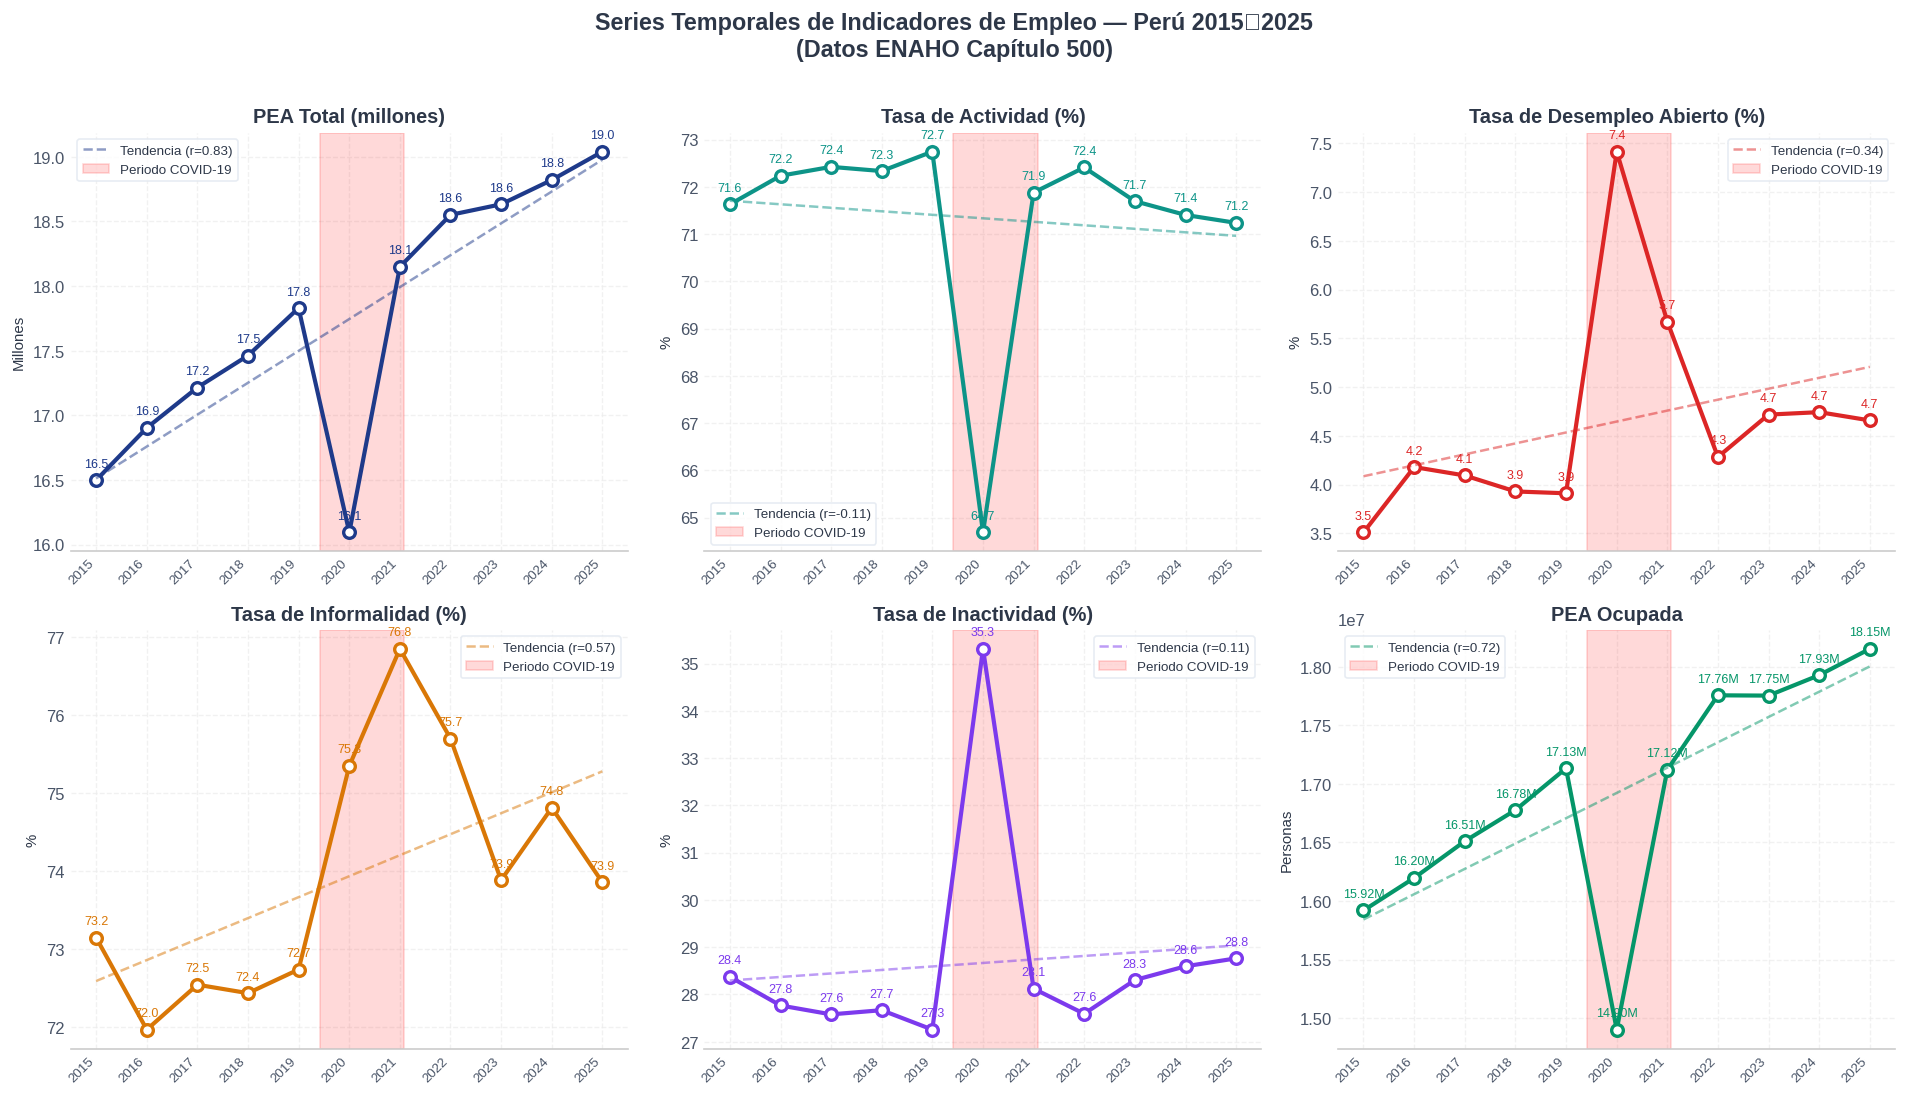

✅ Gráfico guardado: series_temporales_nacionales.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Series Temporales de Indicadores de Empleo — Perú 2015 - 2025\n(Datos ENAHO Capítulo 500)', 
             fontsize=14, fontweight='bold', y=1.01)

series_cfg = [
    ('PEA_millones',      'PEA Total (millones)',           '#1E3A8A', 'Millones'),
    ('Tasa_Actividad',    'Tasa de Actividad (%)',           '#0D9488', '%'),
    ('Tasa_Desempleo',    'Tasa de Desempleo Abierto (%)',   '#DC2626', '%'),
    ('Tasa_Informalidad', 'Tasa de Informalidad (%)',        '#D97706', '%'),
    ('Tasa_Inactividad',  'Tasa de Inactividad (%)',         '#7C3AED', '%'),
    ('Ocupados',          'PEA Ocupada',                     '#059669', 'Personas'),
]

x_dates = pd.to_datetime([f"{yr}-07-01" for yr in YEARS])

for ax, (col, title, color, ylabel) in zip(axes.flat, series_cfg):
    y_vals = df_ind[col]
    ax.plot(x_dates, y_vals, 'o-', color=color, linewidth=2.5, markersize=7,
            markerfacecolor='white', markeredgewidth=2)
    # Tendencia lineal
    slope, intercept, r, p, _ = stats.linregress(YEARS, y_vals.values)
    trend = [slope * yr + intercept for yr in YEARS]
    ax.plot(x_dates, trend, '--', color=color, alpha=0.5, linewidth=1.5, label=f'Tendencia (r={r:.2f})')
    # Anotaciones
    for x_val, val in zip(x_dates, y_vals):
        lbl = f'{val/1e6:.2f}M' if col == 'Ocupados' else f'{val:.1f}'
        ax.annotate(lbl, (x_val, val), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=7.5, color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xticks(x_dates)
    ax.set_xticklabels(YEARS, rotation=45, ha='right', fontsize=8)
    # Sombrear COVID-19
    ax.axvspan(
        pd.Timestamp('2019-12-01'),
        pd.Timestamp('2021-07-31'),
        alpha=0.15,
        color='red',
        label='Periodo COVID-19'
    )
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('imagenes/series_temporales_nacionales.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Gráfico guardado: series_temporales_nacionales.png')


---
## 4. Análisis por Área de Residencia (Urbano / Rural)

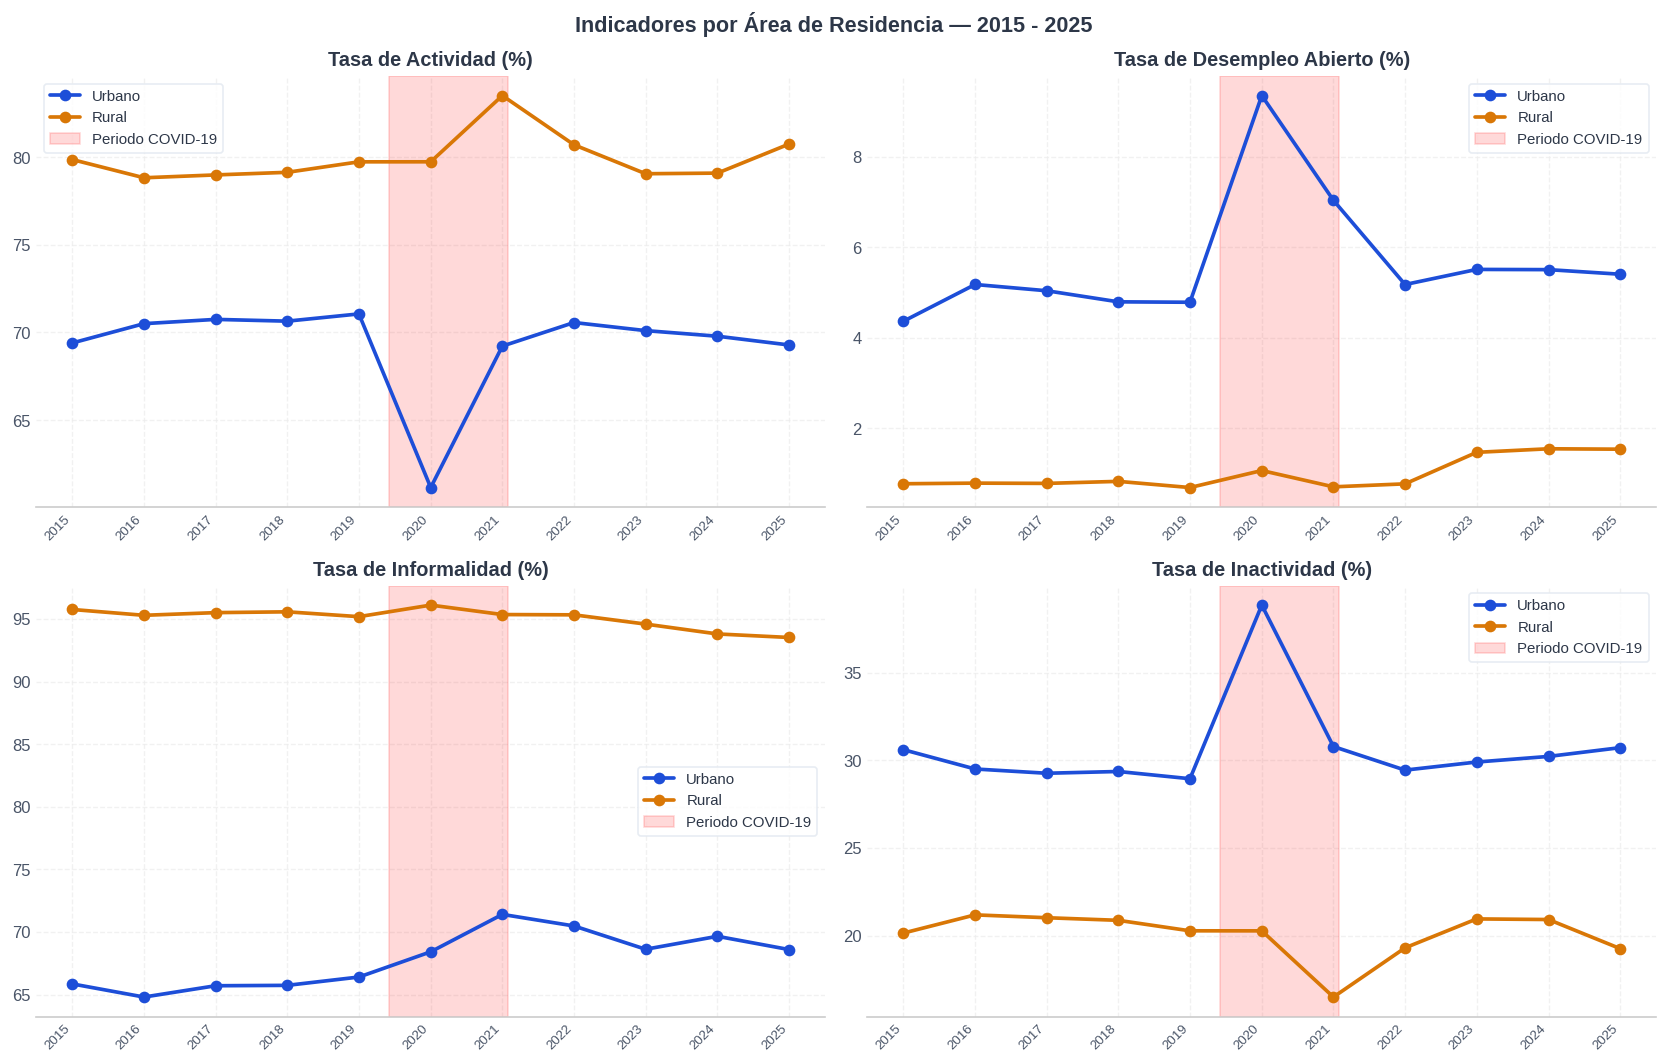

In [6]:
def indicators_by_group(df, group_col, group_label_col, indicators, cond=None):
    """Calcula medias ponderadas de indicadores agrupadas por grupo_col."""
    sub = df[df['RESIDENTE'] == 1].copy()
    if cond is not None:
        sub = sub[cond(sub)]
    edad = pd.to_numeric(sub.get('P208A', pd.Series(np.nan, index=sub.index)), errors='coerce')
    sub = sub[edad >= 14]
    records = []
    for gval in sorted(sub[group_col].dropna().unique()):
        grp = sub[sub[group_col] == gval]
        w   = grp['FAC500A']
        label = grp[group_label_col].iloc[0] if len(grp) > 0 else gval
        row = {group_label_col: label}
        for ind in indicators:
            if ind == 'TDA':
                pea_ab = grp[grp['OCU500_N'].isin([1,2])]
                row[ind] = wtd_mean(pea_ab[ind], pea_ab['FAC500A']) * 100
            else:
                row[ind] = wtd_mean(grp[ind], w) * 100
        records.append(row)
    return pd.DataFrame(records)

IND_COLS = ['TASA_ACTIVIDAD','TDA','TEI','TASA_INACTIVIDAD']

# ── Series por área ───────────────────────────────────────────────────────
area_series = []
for yr in YEARS:
    tmp = indicators_by_group(dfs[yr], 'AREA', 'AREA_LABEL', IND_COLS)
    tmp['Año'] = yr
    area_series.append(tmp)
df_area = pd.concat(area_series, ignore_index=True)

# Gráfica
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Indicadores por Área de Residencia — 2015 - 2025', fontsize=13, fontweight='bold')
ind_titles = {'TASA_ACTIVIDAD': 'Tasa de Actividad (%)',
              'TDA': 'Tasa de Desempleo Abierto (%)',
              'TEI': 'Tasa de Informalidad (%)',
              'TASA_INACTIVIDAD': 'Tasa de Inactividad (%)'}
colors_area = {'Urbano':'#1D4ED8', 'Rural':'#D97706'}

for ax, col in zip(axes.flat, IND_COLS):
    for area_lbl in ['Urbano','Rural']:
        sub = df_area[df_area['AREA_LABEL'] == area_lbl]
        x_sub = pd.to_datetime(sub['Año'].astype(str) + '-07-01')
        ax.plot(x_sub, sub[col], 'o-', label=area_lbl,
                color=colors_area[area_lbl], linewidth=2.2, markersize=6)
    ax.set_title(ind_titles[col], fontweight='bold')
    x_ticks = pd.to_datetime([f"{yr}-07-01" for yr in YEARS])
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(YEARS, rotation=45, ha='right', fontsize=8)
    # Sombrear COVID-19
    ax.axvspan(
        pd.Timestamp('2019-12-01'),
        pd.Timestamp('2021-07-31'),
        alpha=0.15,
        color='red',
        label='Periodo COVID-19'
    )
    ax.legend()

plt.tight_layout()
plt.savefig('imagenes/series_area_residencia.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 5. Análisis por Región Natural (Costa / Sierra / Selva)

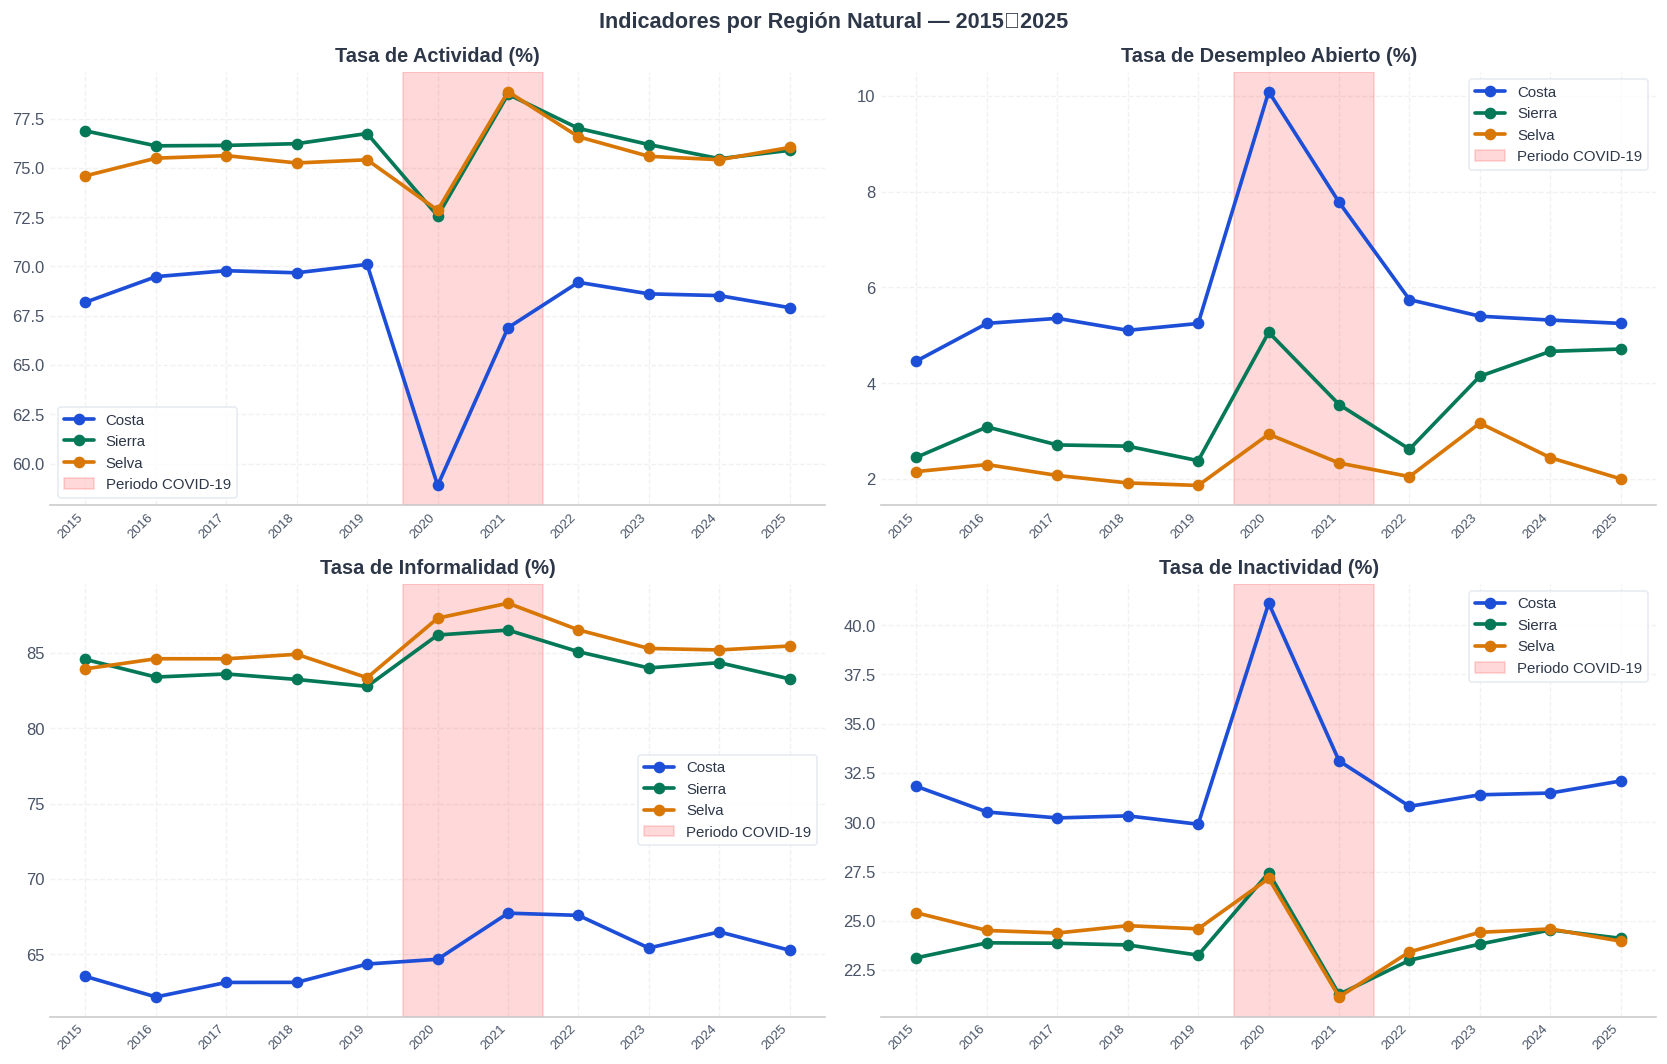

In [7]:
region_series = []
for yr in YEARS:
    tmp = indicators_by_group(dfs[yr], 'REGION', 'REGION_LABEL', IND_COLS)
    tmp['Año'] = yr
    region_series.append(tmp)
df_region = pd.concat(region_series, ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Indicadores por Región Natural — 2015‑2025', fontsize=13, fontweight='bold')
colors_reg = {'Costa':'#1D4ED8', 'Sierra':'#047857', 'Selva':'#D97706'}

for ax, col in zip(axes.flat, IND_COLS):
    for reg in ['Costa','Sierra','Selva']:
        sub = df_region[df_region['REGION_LABEL'] == reg]
        x_sub = pd.to_datetime(sub['Año'].astype(str) + '-07-01')
        ax.plot(x_sub, sub[col], 'o-', label=reg,
                color=colors_reg[reg], linewidth=2.2, markersize=6)
    ax.set_title(ind_titles[col], fontweight='bold')
    x_ticks = pd.to_datetime([f"{yr}-07-01" for yr in YEARS])
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(YEARS, rotation=45, ha='right', fontsize=8)
    # Sombrear COVID-19
    ax.axvspan(
        pd.Timestamp('2020-01-01'),
        pd.Timestamp('2021-12-31'),
        alpha=0.15,
        color='red',
        label='Periodo COVID-19'
    )
    ax.legend()

plt.tight_layout()
plt.savefig('imagenes/series_region_natural.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 6. Análisis por Sexo

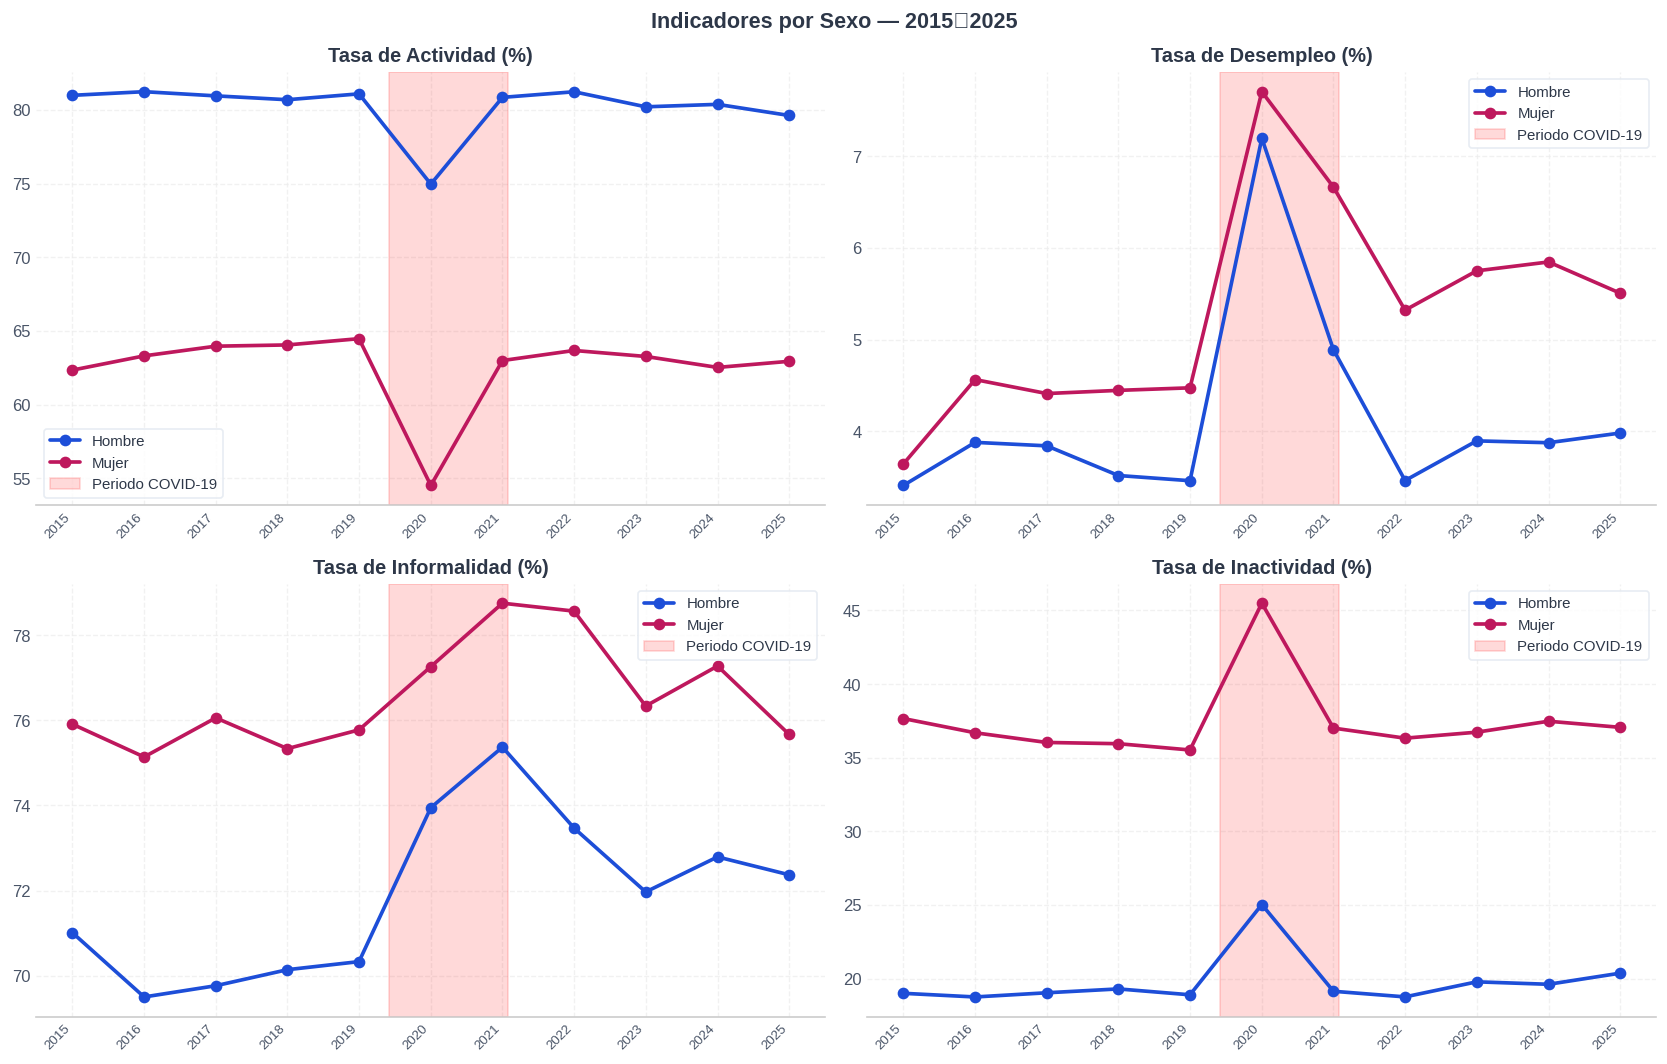

In [8]:
def indicators_by_sexo(df):
    sub = df[df['RESIDENTE'] == 1].copy()
    edad = pd.to_numeric(sub.get('P208A', pd.Series(np.nan, index=sub.index)), errors='coerce')
    sub = sub[edad >= 14]
    records = []
    for sexo_val, sexo_lbl in [(1,'Hombre'), (2,'Mujer')]:
        grp = sub[pd.to_numeric(sub.get('P207', pd.Series(np.nan, index=sub.index)), errors='coerce') == sexo_val]
        w = grp['FAC500A']
        pea_ab = grp[grp['OCU500_N'].isin([1,2])]
        records.append({
            'Sexo': sexo_lbl,
            'Tasa_Actividad': wtd_mean(grp['TASA_ACTIVIDAD'], w) * 100,
            'Tasa_Desempleo': wtd_mean(pea_ab['TDA'], pea_ab['FAC500A']) * 100,
            'Tasa_Informalidad': wtd_mean(grp['TEI'], w) * 100,
            'Tasa_Inactividad': wtd_mean(grp['TASA_INACTIVIDAD'], w) * 100,
        })
    return pd.DataFrame(records)

sexo_series = []
for yr in YEARS:
    tmp = indicators_by_sexo(dfs[yr])
    tmp['Año'] = yr
    sexo_series.append(tmp)
df_sexo = pd.concat(sexo_series, ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Indicadores por Sexo — 2015‑2025', fontsize=13, fontweight='bold')
colors_sx = {'Hombre':'#1D4ED8', 'Mujer':'#BE185D'}
cols_sx = ['Tasa_Actividad','Tasa_Desempleo','Tasa_Informalidad','Tasa_Inactividad']
titles_sx = ['Tasa de Actividad (%)','Tasa de Desempleo (%)','Tasa de Informalidad (%)','Tasa de Inactividad (%)']

for ax, col, ttl in zip(axes.flat, cols_sx, titles_sx):
    for sx in ['Hombre','Mujer']:
        sub = df_sexo[df_sexo['Sexo'] == sx]
        x_sub = pd.to_datetime(sub['Año'].astype(str) + '-07-01')
        ax.plot(x_sub, sub[col], 'o-', label=sx, color=colors_sx[sx], linewidth=2.2, markersize=6)
    ax.set_title(ttl, fontweight='bold')
    x_ticks = pd.to_datetime([f"{yr}-07-01" for yr in YEARS])
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(YEARS, rotation=45, ha='right', fontsize=8)
    # Sombrear COVID-19
    ax.axvspan(
        pd.Timestamp('2019-12-01'),
        pd.Timestamp('2021-07-31'),
        alpha=0.15,
        color='red',
        label='Periodo COVID-19'
    )
    ax.legend()

plt.tight_layout()
plt.savefig('imagenes/series_por_sexo.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 7. Análisis por Grupo de Edad

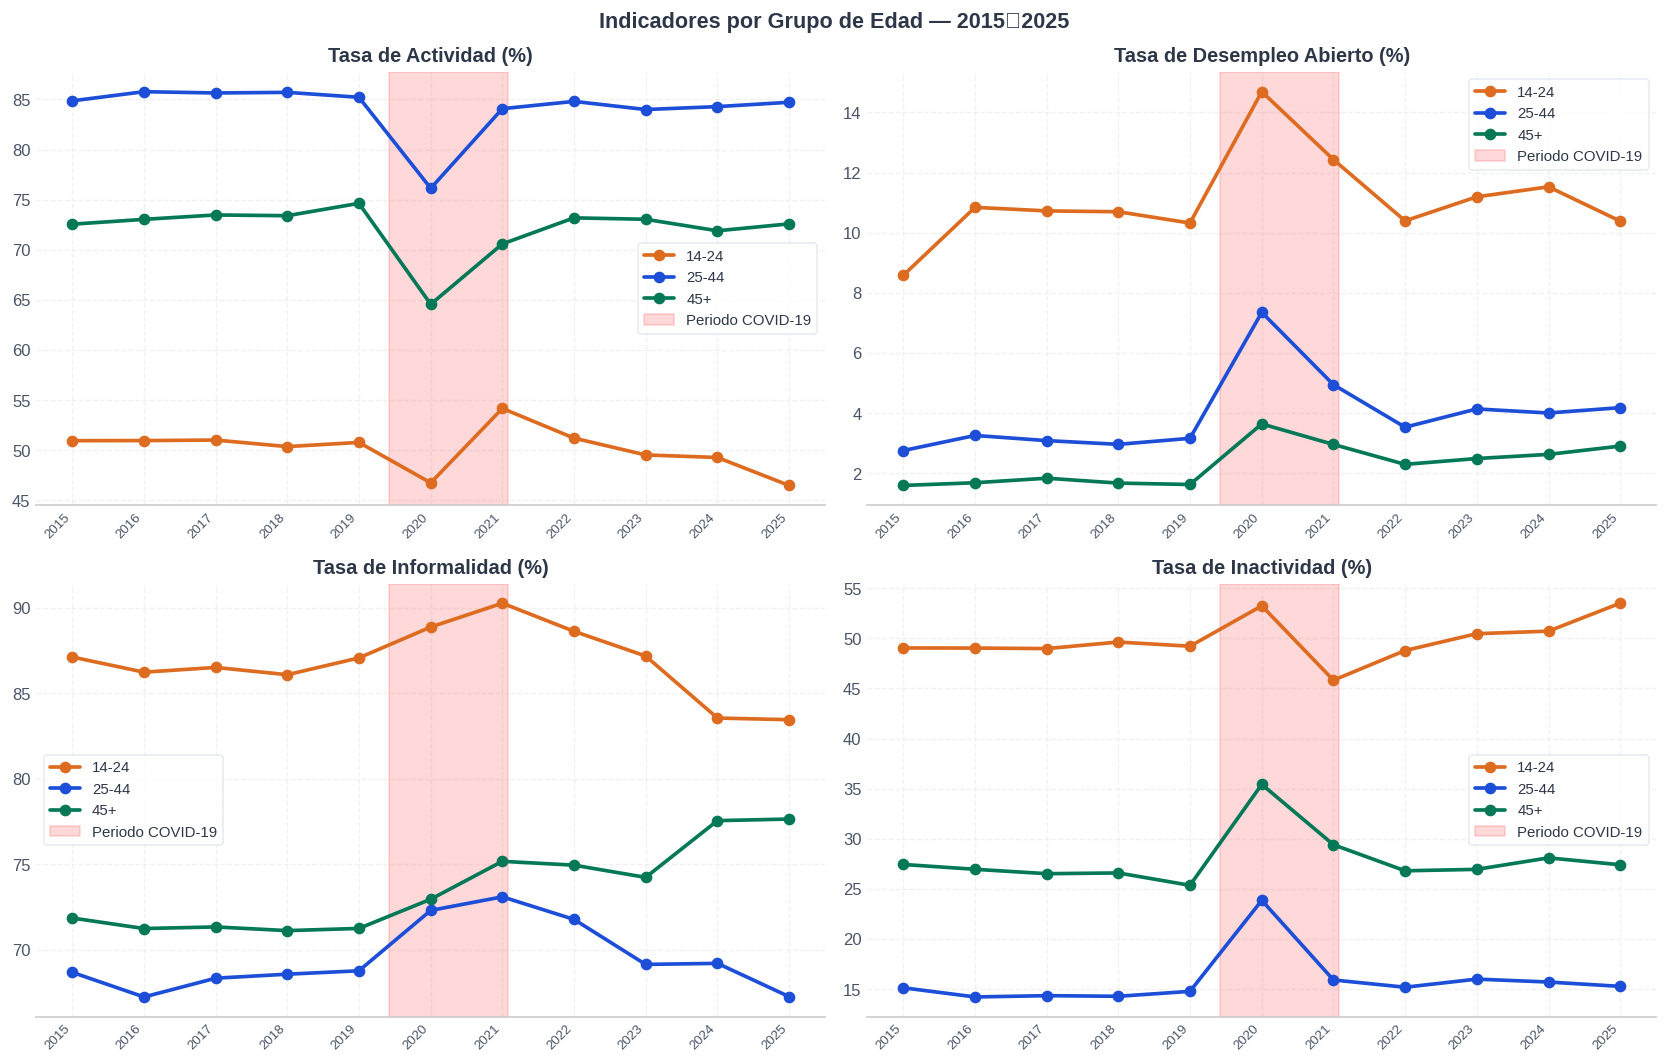

In [ ]:
gedad_series = []
for yr in YEARS:
    tmp = indicators_by_group(dfs[yr], 'GEDAD', 'GEDAD_LABEL', IND_COLS)
    tmp['Año'] = yr
    gedad_series.append(tmp)
df_gedad = pd.concat(gedad_series, ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Indicadores por Grupo de Edad — 2015-2025', fontsize=13, fontweight='bold')
colors_gg = {'14-24':'#DD6B20', '25-44':'#1D4ED8', '45+':'#047857'}

for ax, col in zip(axes.flat, IND_COLS):
    for gg in ['14-24','25-44','45+']:
        sub = df_gedad[df_gedad['GEDAD_LABEL'] == gg]
        x_sub = pd.to_datetime(sub['Año'].astype(str) + '-07-01')
        ax.plot(x_sub, sub[col], 'o-', label=gg, color=colors_gg[gg], linewidth=2.2, markersize=6)
    ax.set_title(ind_titles[col], fontweight='bold')
    x_ticks = pd.to_datetime([f"{yr}-07-01" for yr in YEARS])
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(YEARS, rotation=45, ha='right', fontsize=8)
    # Sombrear COVID-19
    ax.axvspan(
        pd.Timestamp('2019-12-01'),
        pd.Timestamp('2021-07-31'),
        alpha=0.15,
        color='red',
        label='Periodo COVID-19'
    )
    ax.legend()

plt.tight_layout()
plt.savefig('imagenes/series_grupo_edad.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 8. Heatmap de Indicadores por Departamento (Promedio 2015‑2025)

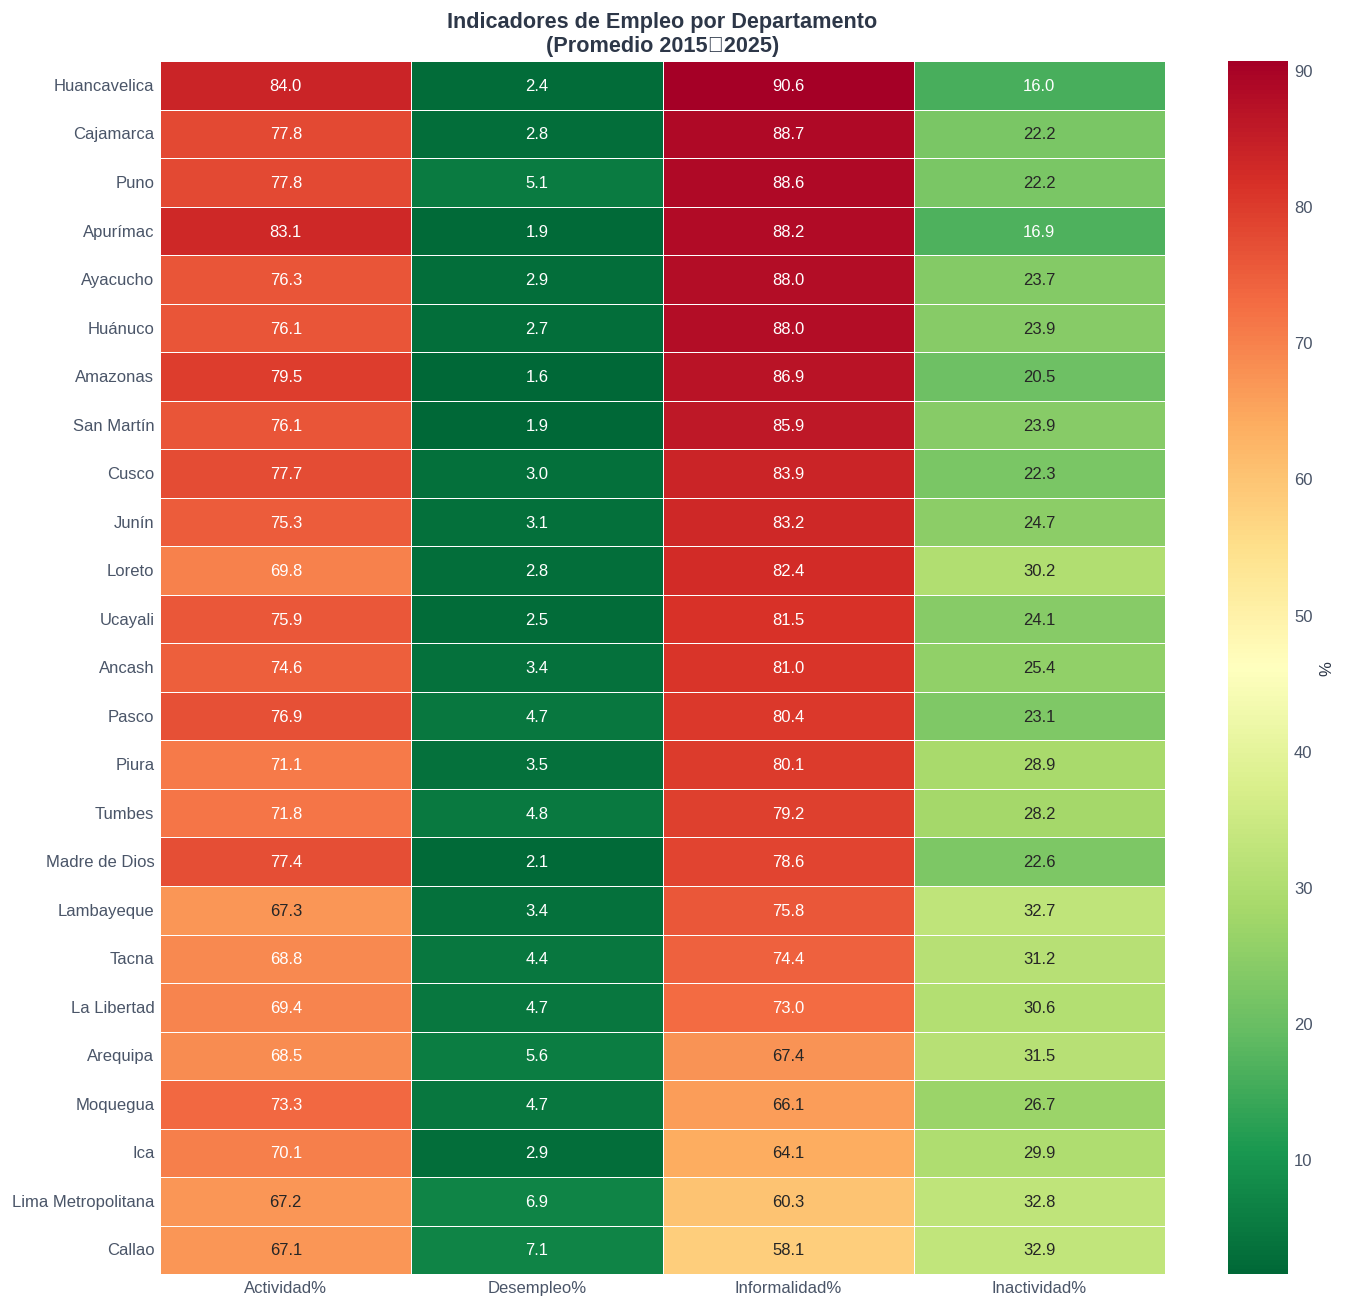

In [10]:
dep_rows = []
for yr in YEARS:
    tmp = indicators_by_group(dfs[yr], 'DEP', 'DEP_LABEL', IND_COLS)
    tmp['Año'] = yr
    dep_rows.append(tmp)
df_dep_all = pd.concat(dep_rows, ignore_index=True)

# Promedio por departamento
df_dep_avg = df_dep_all.groupby('DEP_LABEL')[IND_COLS].mean().rename(columns={
    'TASA_ACTIVIDAD':'Actividad%','TDA':'Desempleo%','TEI':'Informalidad%','TASA_INACTIVIDAD':'Inactividad%'
})
df_dep_avg = df_dep_avg.sort_values('Informalidad%', ascending=False)

fig, ax = plt.subplots(figsize=(12, 11))
sns.heatmap(df_dep_avg, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label':'%'})
ax.set_title('Indicadores de Empleo por Departamento\n(Promedio 2015‑2025)', fontweight='bold', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('imagenes/heatmap_departamentos.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 9. Series Temporales por Departamento — Informalidad

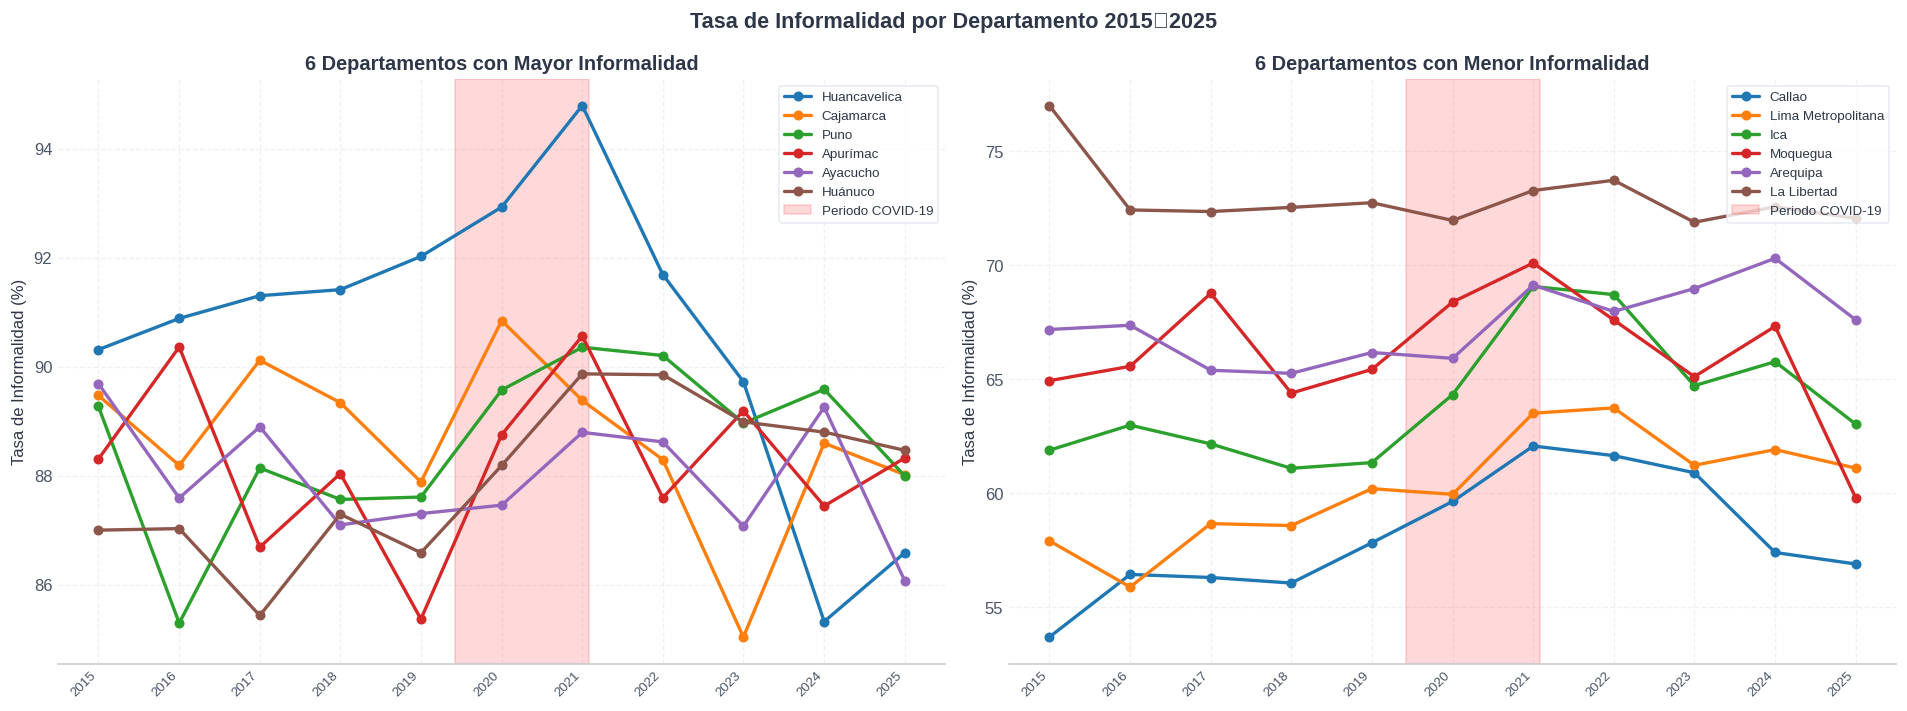

In [ ]:
# Top 6 departamentos con mayor informalidad promedio
top_dep = df_dep_avg['Informalidad%'].nlargest(6).index.tolist()
bot_dep = df_dep_avg['Informalidad%'].nsmallest(6).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Tasa de Informalidad por Departamento 2015-2025', fontsize=13, fontweight='bold')

for ax, deps, title in zip(axes, [top_dep, bot_dep],
                           ['6 Departamentos con Mayor Informalidad', '6 Departamentos con Menor Informalidad']):
    palette = sns.color_palette('tab10', len(deps))
    for dep, color in zip(deps, palette):
        sub = df_dep_all[df_dep_all['DEP_LABEL'] == dep]
        x_sub = pd.to_datetime(sub['Año'].astype(str) + '-07-01')
        ax.plot(x_sub, sub['TEI'], 'o-', label=dep, color=color, linewidth=2, markersize=5)
    ax.set_title(title, fontweight='bold')
    x_ticks = pd.to_datetime([f"{yr}-07-01" for yr in YEARS])
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(YEARS, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Tasa de Informalidad (%)')
    # Sombrear COVID-19
    ax.axvspan(
        pd.Timestamp('2019-12-01'),
        pd.Timestamp('2021-07-31'),
        alpha=0.15,
        color='red',
        label='Periodo COVID-19'
    )
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('imagenes/series_informalidad_dep.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 10. Estadísticas Comparativas Inter‑anuales

In [12]:
# ── Variación anual (cambio absoluto y relativo) ──────────────────────────
cols_var = ['Tasa_Actividad','Tasa_Desempleo','Tasa_Informalidad','Tasa_Inactividad','PEA_millones']
df_var = df_ind[cols_var].diff().rename(columns=lambda c: c + '_Δ')
df_var_pct = df_ind[cols_var].pct_change() * 100
df_var_pct.columns = [c + '_Δ%' for c in cols_var]

df_summary = pd.concat([df_ind[cols_var], df_var, df_var_pct], axis=1)

print('=== Variación Anual de Indicadores ===')
display(df_summary[['Tasa_Actividad','Tasa_Actividad_Δ',
                     'Tasa_Desempleo','Tasa_Desempleo_Δ',
                     'Tasa_Informalidad','Tasa_Informalidad_Δ',
                     'PEA_millones','PEA_millones_Δ']].style
        .format('{:.2f}')
        .background_gradient(cmap='RdYlGn_r', subset=['Tasa_Desempleo_Δ','Tasa_Informalidad_Δ'])
        .background_gradient(cmap='RdYlGn',   subset=['Tasa_Actividad_Δ']))

=== Variación Anual de Indicadores ===


,Tasa_Actividad,Tasa_Actividad_Δ,Tasa_Desempleo,Tasa_Desempleo_Δ,Tasa_Informalidad,Tasa_Informalidad_Δ,PEA_millones,PEA_millones_Δ
Año,,,,,,,,
2015,71.63,nan,3.51,nan,73.15,nan,16.50,nan
2016,72.23,0.61,4.18,0.67,71.97,-1.18,16.90,0.41
2017,72.42,0.19,4.09,-0.09,72.55,0.57,17.22,0.31
2018,72.33,-0.09,3.93,-0.16,72.44,-0.11,17.46,0.25
2019,72.74,0.41,3.91,-0.02,72.74,0.30,17.83,0.37
2020,64.69,-8.06,7.41,3.50,75.35,2.61,16.09,-1.74
2021,71.88,7.19,5.67,-1.74,76.85,1.50,18.15,2.05
2022,72.41,0.53,4.28,-1.39,75.70,-1.15,18.55,0.40
2023,71.70,-0.71,4.72,0.43,73.88,-1.81,18.63,0.08


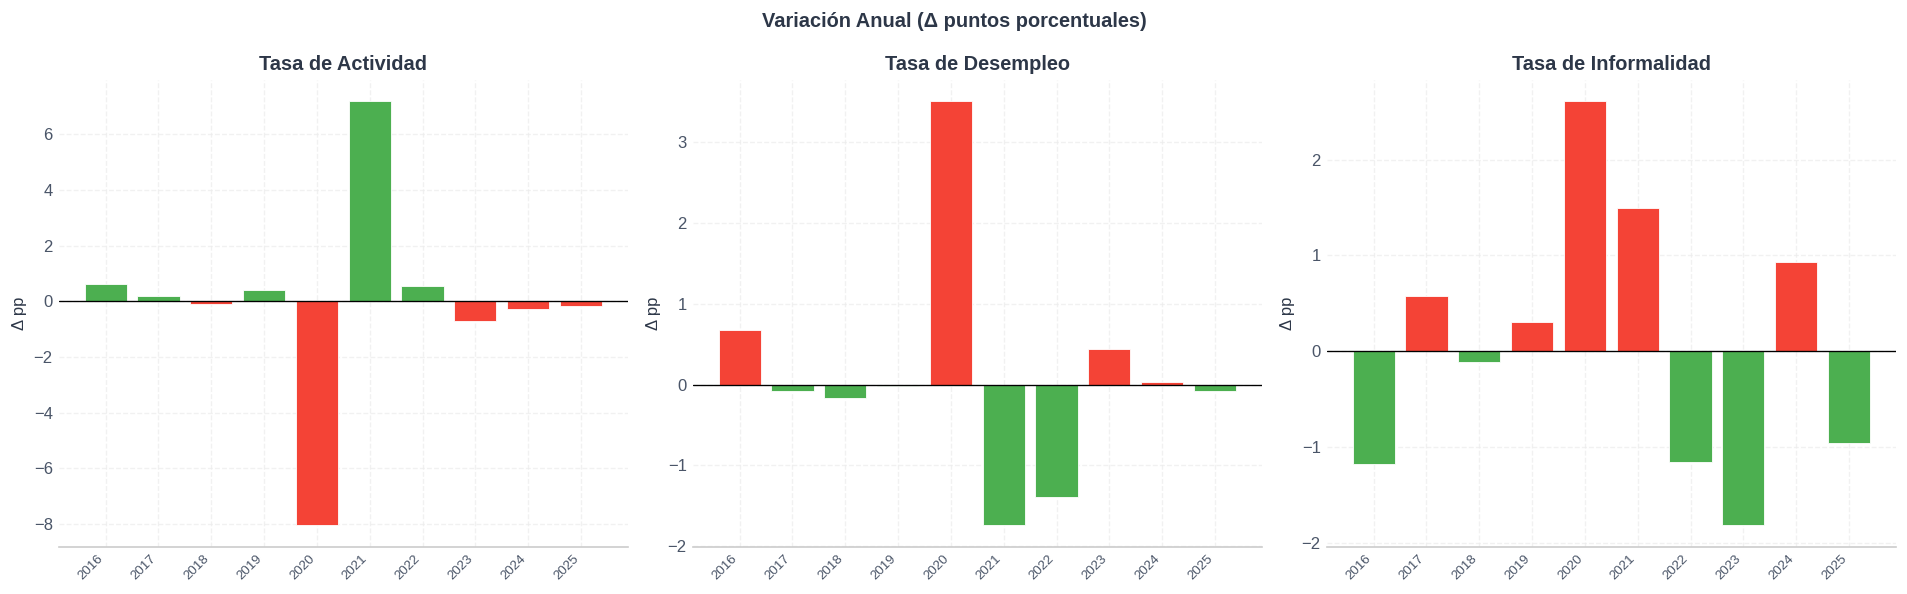

In [13]:
# ── Gráfico de variación anual en barras ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Variación Anual (Δ puntos porcentuales)', fontsize=12, fontweight='bold')

bar_cfg = [
    ('Tasa_Actividad_Δ',    'Tasa de Actividad',    'RdYlGn'),
    ('Tasa_Desempleo_Δ',    'Tasa de Desempleo',    'RdYlGn_r'),
    ('Tasa_Informalidad_Δ', 'Tasa de Informalidad', 'RdYlGn_r'),
]
for ax, (col, title, cmap) in zip(axes, bar_cfg):
    vals = df_var[col].dropna()
    colors = ['#4CAF50' if v >= 0 else '#F44336' for v in vals]
    if cmap.endswith('_r'):
        colors = ['#F44336' if v >= 0 else '#4CAF50' for v in vals]
    ax.bar(vals.index, vals.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(vals.index)
    ax.set_xticklabels(vals.index, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Δ pp')

plt.tight_layout()
plt.savefig('imagenes/variacion_anual_barras.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 11. Distribución de Indicadores — Boxplot por Año

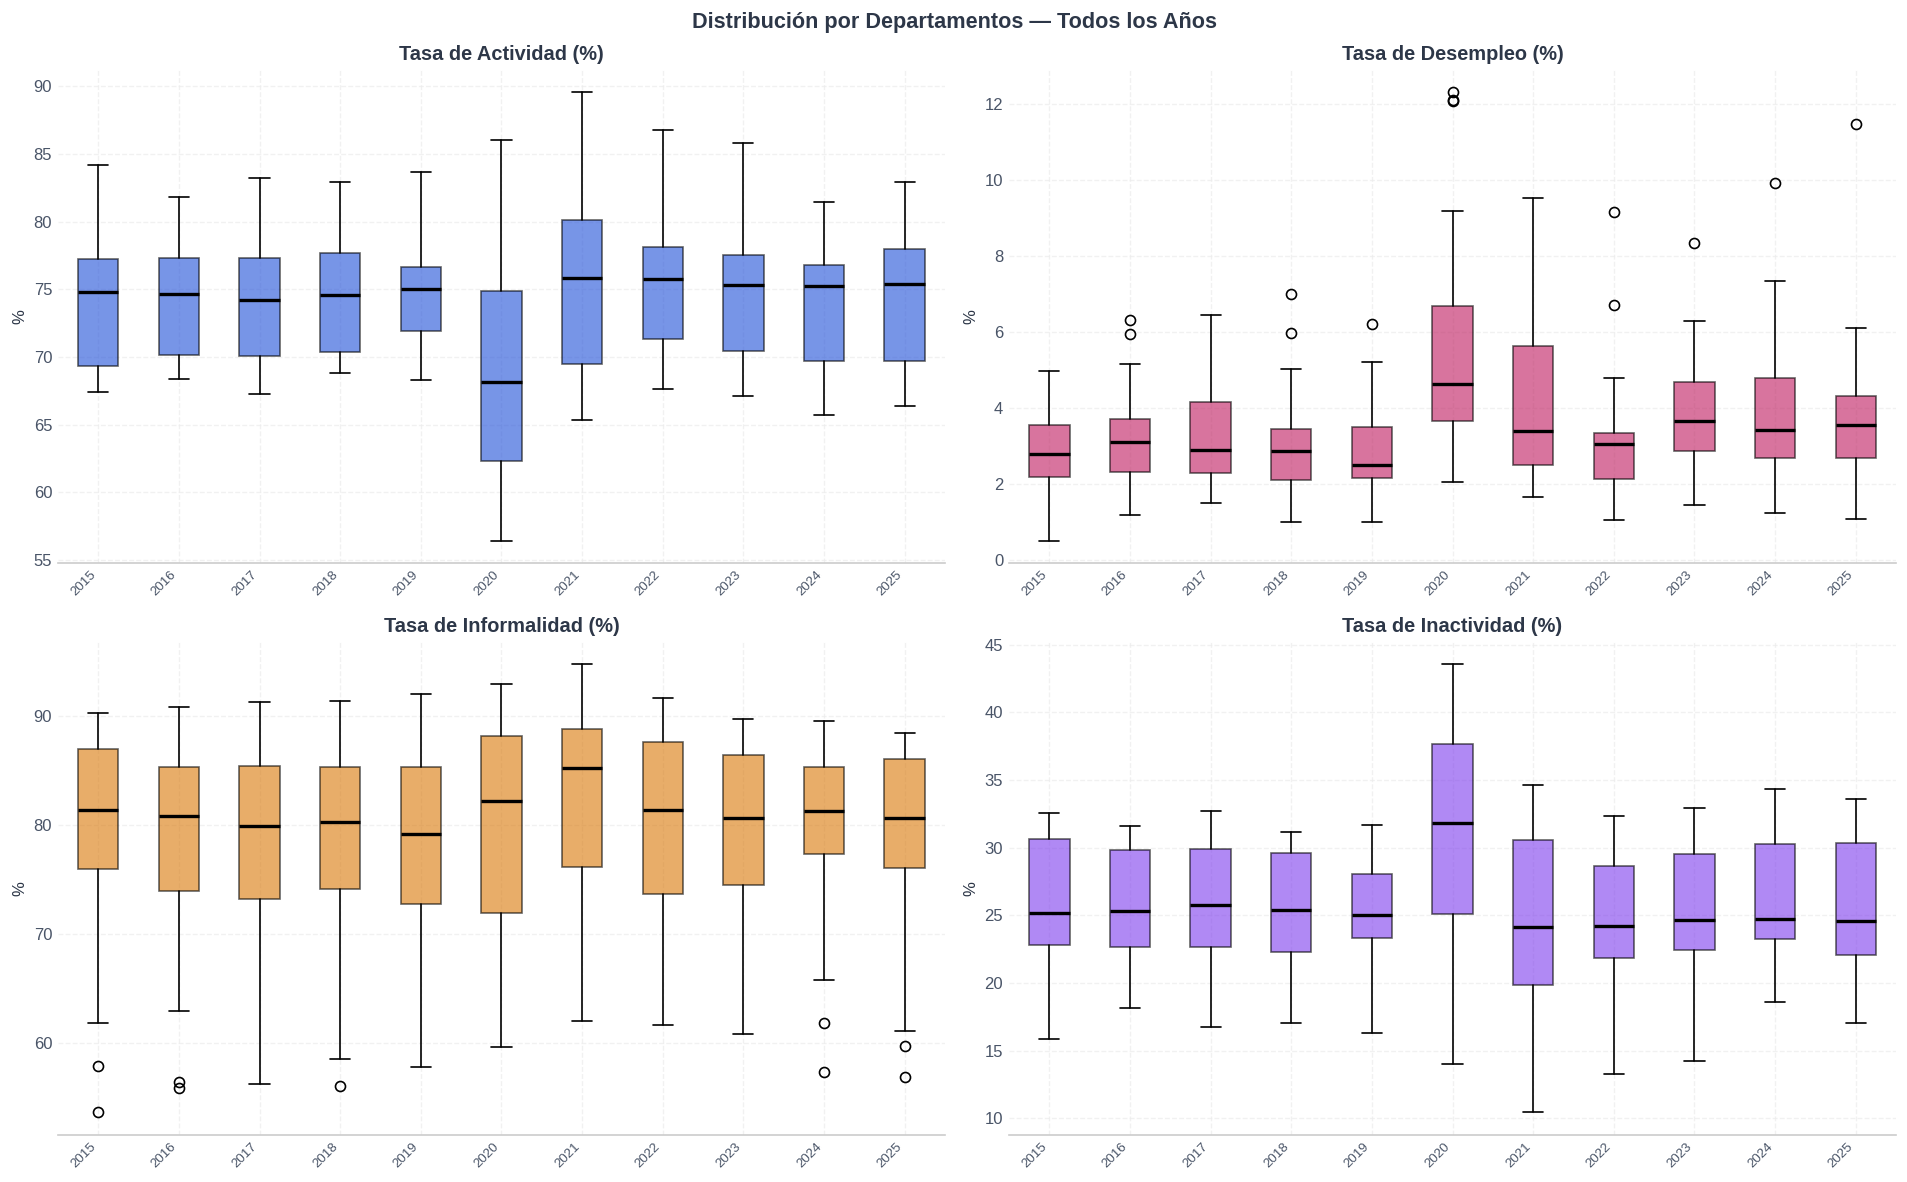

In [14]:
# Usamos microdata ponderada: expandimos el dep_all
df_box = df_dep_all[['Año','TASA_ACTIVIDAD','TDA','TEI','TASA_INACTIVIDAD']].copy()
df_box.columns = ['Año','Actividad','Desempleo','Informalidad','Inactividad']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distribución por Departamentos — Todos los Años', fontsize=13, fontweight='bold')
box_cfg = [('Actividad','Tasa de Actividad (%)','#1D4ED8'),
           ('Desempleo','Tasa de Desempleo (%)','#BE185D'),
           ('Informalidad','Tasa de Informalidad (%)','#D97706'),
           ('Inactividad','Tasa de Inactividad (%)','#7C3AED')]

for ax, (col, title, color) in zip(axes.flat, box_cfg):
    data_by_yr = [df_box[df_box['Año'] == yr][col].dropna().values for yr in YEARS]
    bp = ax.boxplot(data_by_yr, patch_artist=True, labels=YEARS, 
                    medianprops={'color':'black','linewidth':2})
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(YEARS, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('%')

plt.tight_layout()
plt.savefig('imagenes/boxplot_distribucion_anual.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 11b. Histogramas de Distribución Regional (Departamental) 2015-2025

Para complementar el análisis de dispersión, a continuación se presentan los **histogramas de frecuencias con porcentajes** para cada uno de los cuatro indicadores a nivel departamental. Estos gráficos muestran qué porcentaje de departamentos del país se ubican en cada rango de tasas, junto con su curva de densidad estimada (KDE) y la media nacional ponderada como referencia.

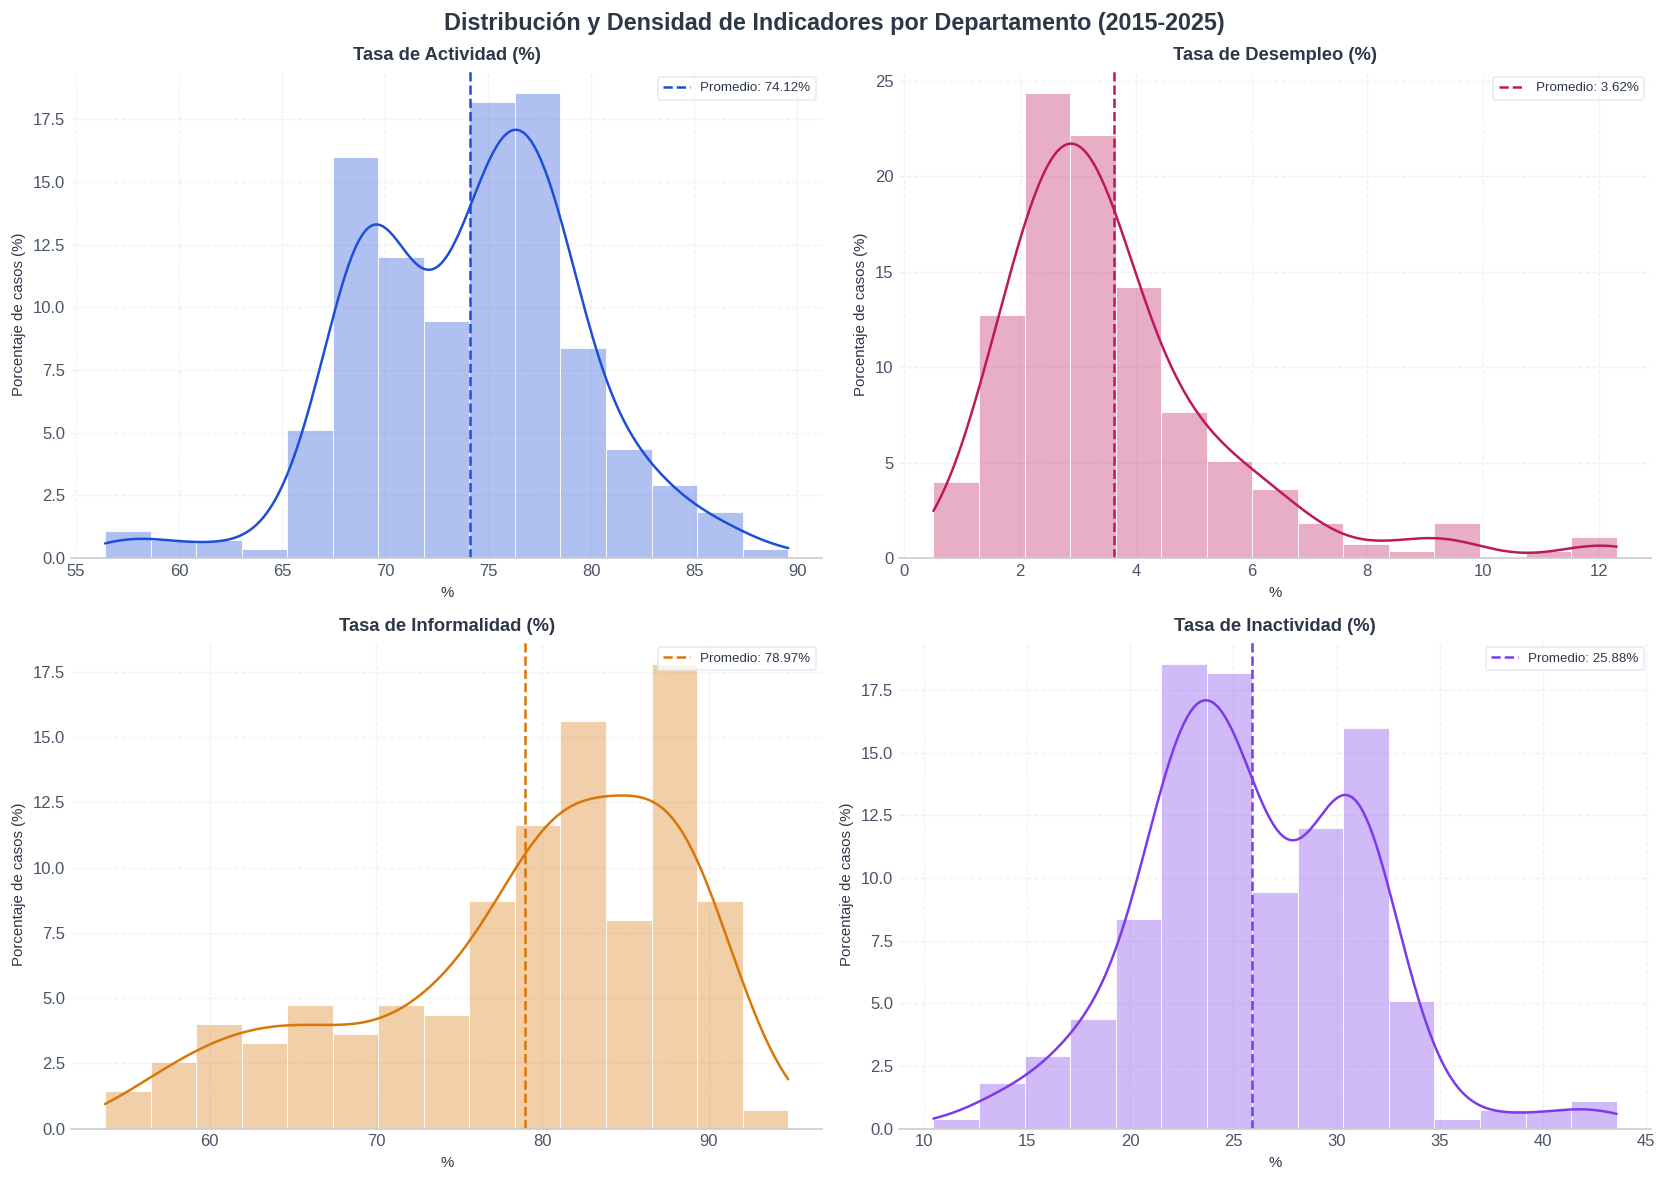

✅ Gráfico guardado: histogramas_departamentales.png


In [15]:
# Panel de histogramas 2x2 para indicadores departamentales
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución y Densidad de Indicadores por Departamento (2015-2025)', fontsize=14, fontweight='bold', y=0.98)

hist_cfg = [
    ('Actividad', 'Tasa de Actividad (%)', '#1D4ED8'),     # Cobalt
    ('Desempleo', 'Tasa de Desempleo (%)', '#BE185D'),     # Muted red/crimson
    ('Informalidad', 'Tasa de Informalidad (%)', '#D97706'), # Amber
    ('Inactividad', 'Tasa de Inactividad (%)', '#7C3AED')   # Purple
]

for ax, (col, title, color) in zip(axes.flat, hist_cfg):
    # Histograma con porcentajes y KDE
    sns.histplot(data=df_box, x=col, kde=True, stat="percent", color=color, alpha=0.35, ax=ax, bins=15, edgecolor='white', linewidth=0.5)
    
    # Calcular y trazar promedio global
    avg_val = df_box[col].mean()
    ax.axvline(avg_val, color=color, linestyle='--', linewidth=1.5, label=f'Promedio: {avg_val:.2f}%')
    
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('%', fontsize=9)
    ax.set_ylabel('Porcentaje de casos (%)', fontsize=9)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('imagenes/histogramas_departamentales.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Gráfico guardado: histogramas_departamentales.png')

---
## 12. Correlación entre Indicadores (Promedio Nacional)

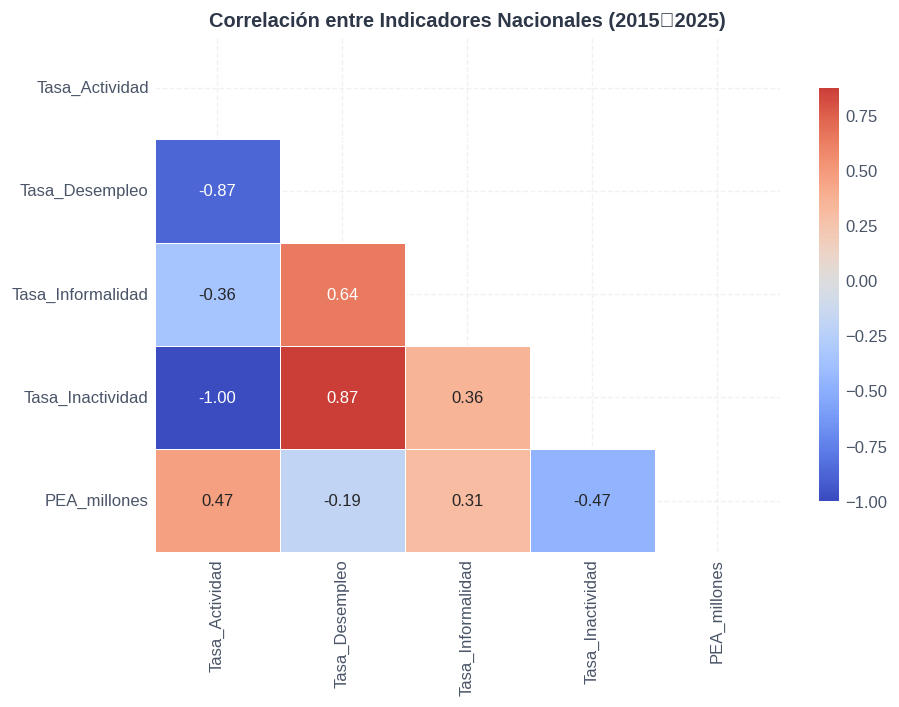

                   Tasa_Actividad  Tasa_Desempleo  Tasa_Informalidad  \
Tasa_Actividad              1.000          -0.873             -0.356   
Tasa_Desempleo             -0.873           1.000              0.642   
Tasa_Informalidad          -0.356           0.642              1.000   
Tasa_Inactividad           -1.000           0.873              0.356   
PEA_millones                0.469          -0.189              0.307   

                   Tasa_Inactividad  PEA_millones  
Tasa_Actividad               -1.000         0.469  
Tasa_Desempleo                0.873        -0.189  
Tasa_Informalidad             0.356         0.307  
Tasa_Inactividad              1.000        -0.469  
PEA_millones                 -0.469         1.000  


In [16]:
corr_cols = ['Tasa_Actividad','Tasa_Desempleo','Tasa_Informalidad','Tasa_Inactividad','PEA_millones']
corr_matrix = df_ind[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlación entre Indicadores Nacionales (2015‑2025)', fontweight='bold')
plt.tight_layout()
plt.savefig('imagenes/correlacion_indicadores.png', bbox_inches='tight', dpi=150)
plt.show()
print(corr_matrix.round(3))

---
## 13. Análisis de Tendencia y Test Estadístico

In [17]:
from scipy.stats import linregress, kendalltau

print('='*65)
print(f'{"Indicador":<22} {"Tendencia":>12} {"R²":>7} {"p-value":>10} {"Tau-Kendall":>12}')
print('='*65)

trend_results = []
for col in ['Tasa_Actividad','Tasa_Desempleo','Tasa_Informalidad','Tasa_Inactividad']:
    y = df_ind[col].dropna().values
    x = np.array(YEARS[:len(y)])
    slope, intercept, r, p, se = linregress(x, y)
    tau, ptau = kendalltau(x, y)
    direction = '↑ sube' if slope > 0 else '↓ baja'
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f'{col:<22} {slope:>+10.4f}pp/año  {r**2:>5.3f}  {p:>10.4f}{sig}  {tau:>+10.3f}')
    trend_results.append({'Indicador': col, 'Pendiente_pp_año': slope, 'R2': r**2, 'p_valor': p, 'Tau_Kendall': tau})

print('='*65)
print('Sig: * p<0.05  ** p<0.01  *** p<0.001')
df_trends = pd.DataFrame(trend_results)
display(df_trends.round(4))

Indicador                 Tendencia      R²    p-value  Tau-Kendall
Tasa_Actividad            -0.0742pp/año  0.012      0.7495      -0.273
Tasa_Desempleo            +0.1121pp/año  0.118      0.3011      +0.382
Tasa_Informalidad         +0.2685pp/año  0.325      0.0672      +0.382
Tasa_Inactividad          +0.0742pp/año  0.012      0.7495      +0.273
Sig: * p<0.05  ** p<0.01  *** p<0.001


,Indicador,Pendiente_pp_año,R2,p_valor,Tau_Kendall
0,Tasa_Actividad,-0.0742,0.0119,0.7495,-0.2727
1,Tasa_Desempleo,0.1121,0.1180,0.3011,0.3818
2,Tasa_Informalidad,0.2685,0.3247,0.0672,0.3818
3,Tasa_Inactividad,0.0742,0.0119,0.7495,0.2727


---
## 14. Estadísticas Descriptivas Completas por Año

In [18]:
print('=== Estadísticas Descriptivas de Indicadores Departamentales por Año ===')
for yr in YEARS:
    sub = df_dep_all[df_dep_all['Año'] == yr][IND_COLS].rename(columns={
        'TASA_ACTIVIDAD':'Actividad%','TDA':'Desempleo%','TEI':'Informalidad%','TASA_INACTIVIDAD':'Inactividad%'
    })
    print(f'\n── {yr} ──────────────────────────────')
    display(sub.describe().round(2))

=== Estadísticas Descriptivas de Indicadores Departamentales por Año ===

── 2015 ──────────────────────────────


,Actividad%,Desempleo%,Informalidad%,Inactividad%
count,25.00,25.00,25.00,25.00
mean,74.01,2.87,78.47,25.99
std,4.91,1.14,10.26,4.91
min,67.43,0.50,53.70,15.84
25%,69.34,2.17,76.03,22.77
50%,74.80,2.79,81.41,25.20
75%,77.23,3.56,87.00,30.66
max,84.16,4.96,90.31,32.57



── 2016 ──────────────────────────────


,Actividad%,Desempleo%,Informalidad%,Inactividad%
count,25.00,25.00,25.00,25.00
mean,74.37,3.23,78.37,25.63
std,4.08,1.31,9.93,4.08
min,68.40,1.18,55.89,18.17
25%,70.15,2.32,73.94,22.67
50%,74.66,3.10,80.86,25.34
75%,77.33,3.71,85.30,29.85
max,81.83,6.31,90.89,31.60



── 2017 ──────────────────────────────


...

,Actividad%,Desempleo%,Informalidad%,Inactividad%
count,25.00,25.00,25.00,25.00
mean,74.91,3.99,79.05,25.09
std,4.81,1.56,8.96,4.81
min,67.10,1.44,60.91,14.22
25%,70.45,2.87,74.57,22.45
50%,75.34,3.65,80.67,24.66
75%,77.55,4.68,86.44,29.55
max,85.78,8.34,89.73,32.90



── 2024 ──────────────────────────────


,Actividad%,Desempleo%,Informalidad%,Inactividad%
count,25.00,25.00,25.00,25.00
mean,73.96,3.95,79.41,26.04
std,4.40,1.93,8.83,4.40
min,65.69,1.24,57.41,18.58
25%,69.73,2.67,77.40,23.23
50%,75.27,3.42,81.35,24.73
75%,76.77,4.80,85.33,30.27
max,81.42,9.92,89.59,34.31



── 2025 ──────────────────────────────


,Actividad%,Desempleo%,Informalidad%,Inactividad%
count,25.00,25.00,25.00,25.00
mean,74.13,3.75,78.52,25.87
std,4.73,2.12,9.74,4.73
min,66.36,1.06,56.90,17.06
25%,69.66,2.69,76.06,22.03
50%,75.42,3.56,80.63,24.58
75%,77.97,4.32,86.07,30.34
max,82.94,11.48,88.47,33.64


---
## 15. Resumen Visual — Indicadores Clave 2015 vs 2025

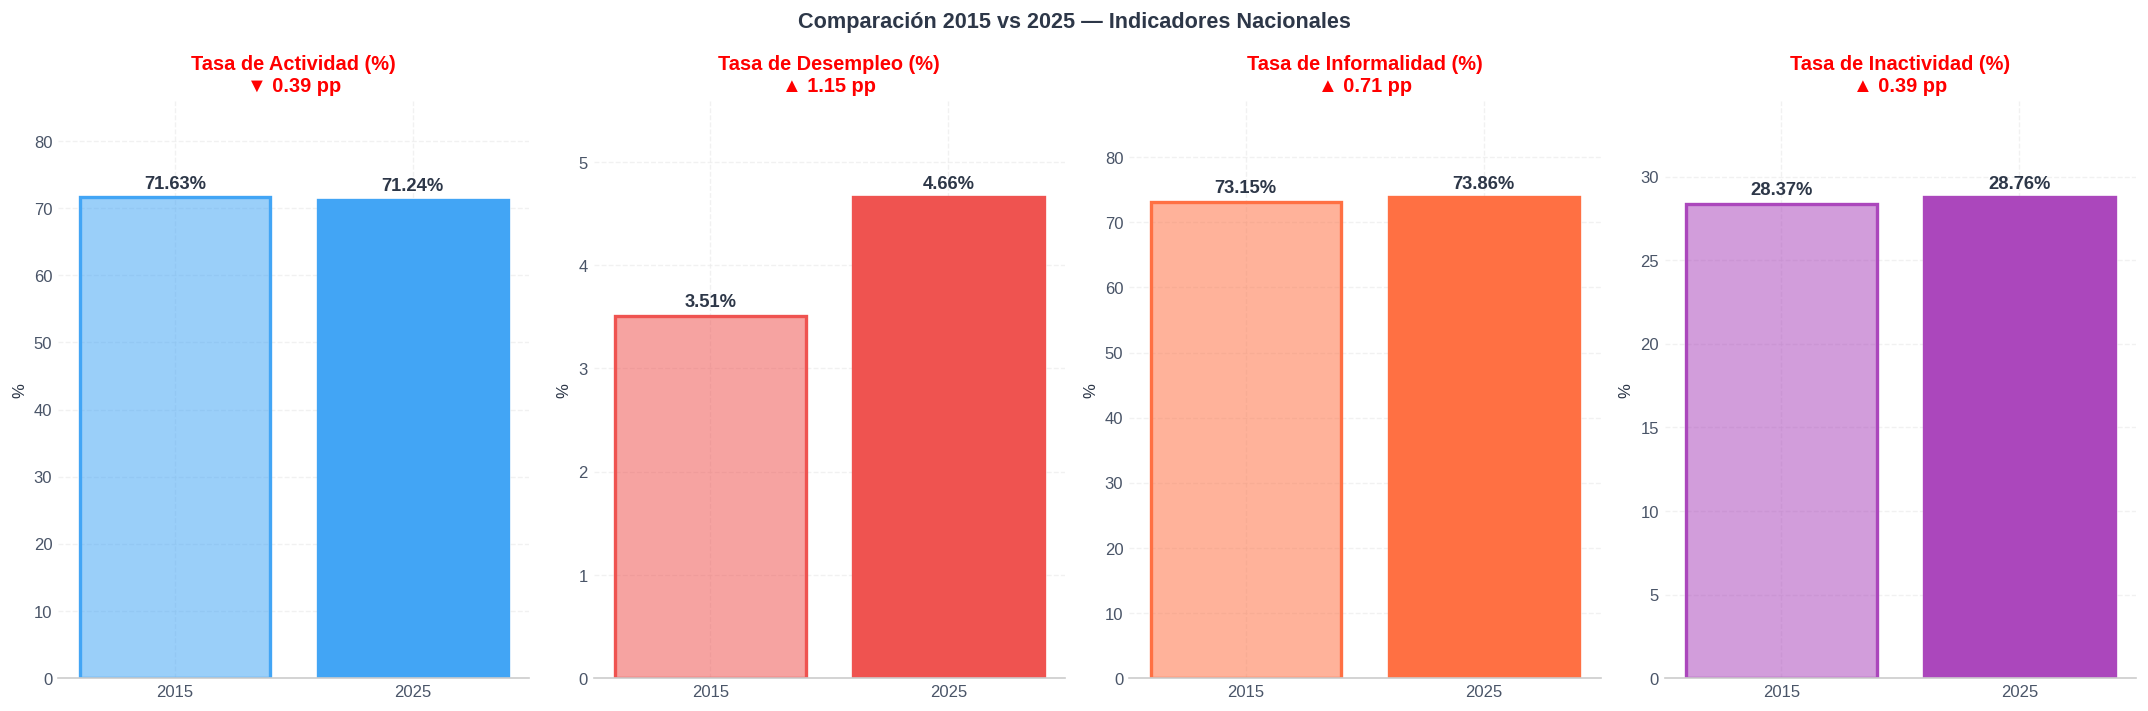

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle('Comparación 2015 vs 2025 — Indicadores Nacionales', fontsize=13, fontweight='bold')

compare_cols = [
    ('Tasa_Actividad',    'Tasa de Actividad (%)',    '#42A5F5'),
    ('Tasa_Desempleo',    'Tasa de Desempleo (%)',    '#EF5350'),
    ('Tasa_Informalidad', 'Tasa de Informalidad (%)', '#FF7043'),
    ('Tasa_Inactividad',  'Tasa de Inactividad (%)',  '#AB47BC'),
]

for ax, (col, title, color) in zip(axes, compare_cols):
    val2015 = df_ind.loc[2015, col]
    val2025 = df_ind.loc[2025, col]
    bars = ax.bar(['2015','2025'], [val2015, val2025], color=[color+'88', color],
                  edgecolor=color, linewidth=2)
    ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=11, fontweight='bold')
    delta = val2025 - val2015
    arrow = '▲' if delta > 0 else '▼'
    col_d = 'green' if (delta > 0 and col == 'Tasa_Actividad') or (delta < 0 and col != 'Tasa_Actividad') else 'red'
    ax.set_title(f'{title}\n{arrow} {abs(delta):.2f} pp', fontweight='bold', color=col_d)
    ax.set_ylim(0, max(val2015, val2025) * 1.2)
    ax.set_ylabel('%')

plt.tight_layout()
plt.savefig('imagenes/comparacion_2015_vs_2025.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 16. Generación del CSV Final para Predicción

In [20]:
# ─────────────────────────────────────────────────────────────────────────
# Construcción del dataset final: una fila por individuo (residente ≥14 años)
# con variables clave para modelado predictivo
# ─────────────────────────────────────────────────────────────────────────
PRED_COLS = [
    # Identificadores
    'AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR', 'UBIGEO',
    # Geográficas (construidas)
    'AREA', 'AREA_LABEL', 'REGION', 'REGION_LABEL', 'DEP', 'DEP_LABEL',
    # Demográficas
    'P207',      # sexo
    'P208A',     # edad
    'P209',      # nivel educativo alcanzado (raw)
    'P301A',     # nivel educación (raw)
    'GEDAD',     # grupo edad
    'GEDAD_LABEL',
    # Condición laboral — VARIABLES TARGET
    'OCU500_N',  # condición ocupación (1=ocupado,2=desoc.ab,3=desoc.oc,4=NoPEA)
    'OCUPINF',   # informalidad (1=inf,2=formal)
    # Indicadores binarios
    'PEA', 'OCUPADO', 'DESOC_ABIERTO', 'DESOC_OCULTO',
    'TASA_ACTIVIDAD', 'TASA_INACTIVIDAD', 'TDA', 'TEI',
    # Factor de expansión
    'FAC500A',
    # Residencia
    'RESIDENTE',
]

dfs_pred = []
for yr in YEARS:
    df_yr = dfs[yr].copy()
    # Solo residentes en PET (≥14)
    edad = pd.to_numeric(df_yr.get('P208A', pd.Series(np.nan, index=df_yr.index)), errors='coerce')
    mask = (df_yr['RESIDENTE'] == 1) & (edad >= 14)
    df_sub = df_yr[mask].copy()
    # Seleccionar columnas disponibles
    avail = [c for c in PRED_COLS if c in df_sub.columns]
    dfs_pred.append(df_sub[avail])

df_final = pd.concat(dfs_pred, ignore_index=True)

# Renombrar P207 → SEXO, P208A → EDAD para claridad
df_final.rename(columns={'P207':'SEXO', 'P208A':'EDAD', 'P209':'NIVEL_EDU',
                          'P301A':'NIVEL_EDU_ALCAN'}, inplace=True)

# Asegurar tipos
num_cols = ['AÑO','MES','AREA','REGION','DEP','SEXO','EDAD',
            'GEDAD','OGEDAD','OCU500_N','OCUPINF','FAC500A',
            'PEA','OCUPADO','DESOC_ABIERTO','DESOC_OCULTO',
            'TASA_ACTIVIDAD','TASA_INACTIVIDAD','TDA','TEI','RESIDENTE']
for c in num_cols:
    if c in df_final.columns:
        df_final[c] = pd.to_numeric(df_final[c], errors='coerce')

print(f'✅ Dataset final: {df_final.shape[0]:,} filas  |  {df_final.shape[1]} columnas')
print(f'   Distribución por año:')
display(df_final.groupby('AÑO').size().rename('n_registros').to_frame().T)

# Guardar
out_path = 'enaho_empleo_2015_2025_final.csv'
df_final.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'\n💾 CSV final guardado: {out_path}')
print(f'   Columnas exportadas: {list(df_final.columns)}')

✅ Dataset final: 973,950 filas  |  30 columnas
   Distribución por año:


AÑO,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
n_registros,85368,94914,91303,97734,90567,89923,85697,86148,84956,84162,83178



💾 CSV final guardado: enaho_empleo_2015_2025_final.csv
   Columnas exportadas: ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR', 'UBIGEO', 'AREA', 'AREA_LABEL', 'REGION', 'REGION_LABEL', 'DEP', 'DEP_LABEL', 'SEXO', 'EDAD', 'NIVEL_EDU', 'NIVEL_EDU_ALCAN', 'GEDAD', 'GEDAD_LABEL', 'OCU500_N', 'OCUPINF', 'PEA', 'OCUPADO', 'DESOC_ABIERTO', 'DESOC_OCULTO', 'TASA_ACTIVIDAD', 'TASA_INACTIVIDAD', 'TDA', 'TEI', 'FAC500A', 'RESIDENTE']


---
## 17. Tabla Nacional Consolidada — Guardada como CSV de Indicadores

In [21]:
# ── Nacional ──────────────────────────────────────────────────────────────
df_ind.to_csv('indicadores_nacionales_2015_2025.csv', encoding='utf-8-sig')

# ── Por área ──────────────────────────────────────────────────────────────
df_area.to_csv('indicadores_area_2015_2025.csv', index=False, encoding='utf-8-sig')

# ── Por región ────────────────────────────────────────────────────────────
df_region.to_csv('indicadores_region_2015_2025.csv', index=False, encoding='utf-8-sig')

# ── Por departamento ──────────────────────────────────────────────────────
df_dep_all.to_csv('indicadores_departamento_2015_2025.csv', index=False, encoding='utf-8-sig')

# ── Por sexo ──────────────────────────────────────────────────────────────
df_sexo.to_csv('indicadores_sexo_2015_2025.csv', index=False, encoding='utf-8-sig')

# ── Por grupo de edad ─────────────────────────────────────────────────────
df_gedad.to_csv('indicadores_gedad_2015_2025.csv', index=False, encoding='utf-8-sig')

# ── Tendencias ────────────────────────────────────────────────────────────
df_trends.to_csv('tendencias_estadisticas.csv', index=False, encoding='utf-8-sig')

print('✅ Todos los CSVs de resumen guardados:')
import glob
for f in sorted(glob.glob('*.csv')):
    size = os.path.getsize(f) / 1024
    print(f'   {f:<50} {size:>8.1f} KB')

✅ Todos los CSVs de resumen guardados:
   enaho_empleo_2015_2025_final.csv                   124171.7 KB
   indicadores_area_2015_2025.csv                          1.9 KB
   indicadores_departamento_2015_2025.csv                 23.3 KB
   indicadores_gedad_2015_2025.csv                         2.7 KB
   indicadores_nacionales_2015_2025.csv                    1.7 KB
   indicadores_region_2015_2025.csv                        2.8 KB
   indicadores_sexo_2015_2025.csv                          1.9 KB
   tendencias_estadisticas.csv                             0.4 KB


---
## 18. Resumen Ejecutivo Final

In [22]:
print('='*65)
print(' RESUMEN EJECUTIVO — EMPLEO PERÚ 2015‑2025 (ENAHO Cap. 500)')
print('='*65)

for col, label in [
    ('Tasa_Actividad',    'Tasa de Actividad'),
    ('Tasa_Desempleo',    'Tasa de Desempleo Abierto'),
    ('Tasa_Informalidad', 'Tasa de Informalidad'),
    ('Tasa_Inactividad',  'Tasa de Inactividad'),
]:
    mn  = df_ind[col].min()
    mx  = df_ind[col].max()
    yr_mn = df_ind[col].idxmin()
    yr_mx = df_ind[col].idxmax()
    prom  = df_ind[col].mean()
    d     = df_ind.loc[2025, col] - df_ind.loc[2015, col]
    print(f'\n{label}')
    print(f'  Promedio 2015‑2025: {prom:.2f}%')
    print(f'  Mínimo:  {mn:.2f}% ({yr_mn})   Máximo: {mx:.2f}% ({yr_mx})')
    print(f'  Cambio 2015→2025:  {d:+.2f} pp')

print('\n' + '='*65)
print(f'  CSV final para predicción: enaho_empleo_2015_2025_final.csv')
print(f'  Registros: {len(df_final):,}  |  Variables: {df_final.shape[1]}')
print('='*65)

 RESUMEN EJECUTIVO — EMPLEO PERÚ 2015‑2025 (ENAHO Cap. 500)

Tasa de Actividad
  Promedio 2015‑2025: 71.33%
  Mínimo:  64.69% (2020)   Máximo: 72.74% (2019)
  Cambio 2015→2025:  -0.39 pp

Tasa de Desempleo Abierto
  Promedio 2015‑2025: 4.65%
  Mínimo:  3.51% (2015)   Máximo: 7.41% (2020)
  Cambio 2015→2025:  +1.15 pp

Tasa de Informalidad
  Promedio 2015‑2025: 73.94%
  Mínimo:  71.97% (2016)   Máximo: 76.85% (2021)
  Cambio 2015→2025:  +0.71 pp

Tasa de Inactividad
  Promedio 2015‑2025: 28.67%
  Mínimo:  27.26% (2019)   Máximo: 35.31% (2020)
  Cambio 2015→2025:  +0.39 pp

  CSV final para predicción: enaho_empleo_2015_2025_final.csv
  Registros: 973,950  |  Variables: 30
